In [ ]:
# Retail Demand Forecasting using Machine Learning

## Notebook 2

# Exploratory Data Analysis (EDA)

---

### Objectives

- Dataset Overview
- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis
- Correlation Analysis
- Business Insights
- Interactive Charts

In [ ]:
# ==============================================================================
# INSTALL REQUIRED LIBRARIES
# ==============================================================================

# Uncomment only if required

# %pip install pandas
# %pip install numpy
# %pip install matplotlib
# %pip install seaborn
# %pip install plotly
# %pip install missingno

In [1]:
# ==============================================================================
# IMPORT LIBRARIES
# ==============================================================================

import warnings
warnings.filterwarnings("ignore")

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import missingno as msno

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==============================================================================
# DISPLAY SETTINGS
# ==============================================================================

plt.style.use("ggplot")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
# ==============================================================================
# PROJECT DIRECTORY
# ==============================================================================

PROJECT_DIR = os.getcwd()

print(PROJECT_DIR)

c:\Users\asus\Desktop\RETAIL\notebook


In [7]:
# ==============================================================================
# LOAD CLEANED DATASET
# ==============================================================================

DATA_PATH = "dataset/retail_cleaned.csv"

df = pd.read_csv(r"C:\Users\asus\Desktop\RETAIL\dataset\retail_cleaned.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [8]:
# ==============================================================================
# DATASET SHAPE
# ==============================================================================

print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 8601
Columns : 33


In [9]:
# ==============================================================================
# FIRST FIVE RECORDS
# ==============================================================================

df.head()

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales,Year,Month,Day,Week,Quarter,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
0,2023-01-01,41,1029,2,0,0,0,2,32.10,107.07,287.06,3.78,452,111.98,102.88,14,278,27,2023,1,1,52,1,3,4,1,3,1.62,9.10,15.68,96.30,0.10,0
1,2023-01-02,46,1167,5,3,0,1,0,18.30,114.77,271.06,4.44,452,713.49,664.33,48,192,54,2023,1,2,1,1,1,4,0,3,2.34,49.16,342.48,371.01,0.28,48
2,2023-01-03,7,1024,3,1,1,1,0,17.90,81.74,235.13,4.12,964,788.14,796.34,40,336,146,2023,1,3,1,1,5,4,0,3,2.86,-8.20,315.26,472.88,0.43,40
3,2023-01-04,13,1181,2,1,0,1,2,35.70,114.66,225.62,7.08,874,761.42,741.65,13,363,135,2023,1,4,1,1,6,4,0,3,2.40,19.77,98.98,662.44,0.37,13
4,2023-01-05,18,1180,5,1,0,0,2,23.90,90.80,291.05,9.19,244,1385.00,1479.97,49,48,0,2023,1,5,1,1,4,4,0,3,4.98,-94.97,678.65,706.35,0.00,0


In [10]:
# ==============================================================================
# LAST FIVE RECORDS
# ==============================================================================

df.tail()

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales,Year,Month,Day,Week,Quarter,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
8596,2024-05-20,22,1006,5,2,0,1,0,31.60,114.27,295.34,8.98,426,383.82,420.18,2,119,48,2024,5,20,21,2,1,8,0,2,3.55,-36.36,7.68,376.14,0.40,2
8597,2024-05-21,35,1177,2,0,0,0,0,21.40,115.54,263.00,4.79,989,1590.48,1480.56,4,418,57,2024,5,21,21,2,5,8,0,2,2.36,109.92,63.62,1526.86,0.14,0
8598,2024-05-22,41,1063,4,0,1,0,0,21.40,88.18,244.49,8.26,150,1601.22,1645.62,50,77,0,2024,5,22,21,2,6,8,0,2,1.92,-44.40,800.61,800.61,0.00,0
8599,2024-05-23,41,1137,4,1,1,0,0,17.50,91.01,250.85,10.81,66,243.18,246.78,24,230,40,2024,5,23,21,2,4,8,0,2,0.29,-3.60,58.36,184.82,0.17,0
8600,2024-05-24,16,1102,1,3,1,1,2,13.70,119.43,270.46,8.50,190,1140.42,1207.26,6,436,199,2024,5,24,21,2,0,8,0,2,0.43,-66.84,68.43,1071.99,0.46,6


In [11]:
# ==============================================================================
# RANDOM SAMPLE
# ==============================================================================

df.sample(10)

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales,Year,Month,Day,Week,Quarter,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
5941,2023-11-23,26,1189,3,2,0,1,1,26.30,99.00,182.47,4.86,915,1879.71,1788.34,23,408,161,2023,11,23,47,4,4,9,0,0,2.24,91.37,432.33,1447.38,0.39,23
5276,2023-09-25,39,1155,6,3,0,1,1,29.40,112.93,215.91,11.86,252,263.37,286.13,1,211,90,2023,9,25,39,3,1,11,0,0,1.19,-22.76,2.63,260.74,0.42,1
5312,2023-11-09,20,1037,6,1,1,0,1,25.40,86.20,290.03,10.50,173,638.86,647.67,40,287,55,2023,11,9,45,4,4,9,0,0,0.60,-8.81,255.54,383.32,0.19,0
7876,2024-01-17,18,1125,3,2,0,0,0,32.30,84.35,288.10,6.24,317,1600.15,1636.12,13,238,27,2024,1,17,3,1,6,4,0,3,1.33,-35.97,208.02,1392.13,0.11,0
1329,2023-04-14,25,1007,3,2,1,1,1,35.40,108.36,226.65,9.54,373,1498.87,1520.54,34,165,60,2023,4,14,15,2,0,0,0,2,2.25,-21.67,509.62,989.25,0.36,34
2852,2024-02-12,30,1185,3,0,0,0,1,16.10,104.01,285.66,6.28,397,1779.62,1893.61,38,405,53,2024,2,12,7,1,1,3,0,3,0.98,-113.99,676.26,1103.36,0.13,0
6966,2023-03-05,15,1191,1,3,1,0,1,26.40,88.51,275.43,9.10,795,1157.74,1163.21,23,190,20,2023,3,5,9,1,3,7,1,2,4.16,-5.47,266.28,891.46,0.10,0
2919,2024-05-02,23,1189,5,3,1,0,2,35.20,112.89,205.04,11.13,686,1581.28,1678.63,33,456,75,2024,5,2,18,2,4,8,0,2,1.50,-97.35,521.82,1059.46,0.16,0
7203,2023-12-05,21,1195,5,3,0,1,2,26.90,88.40,244.88,4.28,618,1046.58,985.76,25,119,45,2023,12,5,49,4,5,2,0,3,5.15,60.82,261.64,784.93,0.38,25
5663,2023-01-03,15,1020,0,3,1,0,0,14.00,86.10,284.91,7.97,324,1434.92,1327.52,7,215,23,2023,1,3,1,1,5,4,0,3,1.50,107.40,100.44,1334.48,0.11,0


In [12]:
# ==============================================================================
# DATASET INFORMATION
# ==============================================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8601 entries, 0 to 8600
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    8601 non-null   str    
 1   Store_ID                8601 non-null   int64  
 2   Product_ID              8601 non-null   int64  
 3   Category                8601 non-null   int64  
 4   Region                  8601 non-null   int64  
 5   Holiday                 8601 non-null   int64  
 6   Promotion               8601 non-null   int64  
 7   Weather                 8601 non-null   int64  
 8   Temperature             8601 non-null   float64
 9   Fuel_Price              8601 non-null   float64
 10  CPI                     8601 non-null   float64
 11  Unemployment            8601 non-null   float64
 12  Inventory               8601 non-null   int64  
 13  Price                   8601 non-null   float64
 14  Competitor_Price        8601 non-null   float64
 15

In [13]:
# ==============================================================================
# DATA TYPES
# ==============================================================================

df.dtypes

Date                          str
Store_ID                    int64
Product_ID                  int64
Category                    int64
Region                      int64
Holiday                     int64
Promotion                   int64
Weather                     int64
Temperature               float64
Fuel_Price                float64
CPI                       float64
Unemployment              float64
Inventory                   int64
Price                     float64
Competitor_Price          float64
Discount                    int64
Customers                   int64
Sales                       int64
Year                        int64
Month                       int64
Day                         int64
Week                        int64
Quarter                     int64
Day_Name                    int64
Month_Name                  int64
Weekend                     int64
Season                      int64
Inventory_Per_Customer    float64
Price_Difference          float64
Discount_Amoun

In [14]:
# ==============================================================================
# DATA TYPES
# ==============================================================================

df.dtypes

Date                          str
Store_ID                    int64
Product_ID                  int64
Category                    int64
Region                      int64
Holiday                     int64
Promotion                   int64
Weather                     int64
Temperature               float64
Fuel_Price                float64
CPI                       float64
Unemployment              float64
Inventory                   int64
Price                     float64
Competitor_Price          float64
Discount                    int64
Customers                   int64
Sales                       int64
Year                        int64
Month                       int64
Day                         int64
Week                        int64
Quarter                     int64
Day_Name                    int64
Month_Name                  int64
Weekend                     int64
Season                      int64
Inventory_Per_Customer    float64
Price_Difference          float64
Discount_Amoun

In [15]:
# ==============================================================================
# COLUMN NAMES
# ==============================================================================

df.columns.tolist()

['Date',
 'Store_ID',
 'Product_ID',
 'Category',
 'Region',
 'Holiday',
 'Promotion',
 'Weather',
 'Temperature',
 'Fuel_Price',
 'CPI',
 'Unemployment',
 'Inventory',
 'Price',
 'Competitor_Price',
 'Discount',
 'Customers',
 'Sales',
 'Year',
 'Month',
 'Day',
 'Week',
 'Quarter',
 'Day_Name',
 'Month_Name',
 'Weekend',
 'Season',
 'Inventory_Per_Customer',
 'Price_Difference',
 'Discount_Amount',
 'Final_Price',
 'Sales_Per_Customer',
 'Promotion_Impact']

In [16]:
# ==============================================================================
# STATISTICAL SUMMARY
# ==============================================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store_ID,8601.00,25.44,14.46,1.00,13.00,26.00,38.00,50.00
Product_ID,8601.00,1101.75,57.79,1001.00,1052.00,1103.00,1152.00,1200.00
Category,8601.00,3.03,2.00,0.00,1.00,3.00,5.00,6.00
Region,8601.00,1.51,1.12,0.00,1.00,2.00,3.00,3.00
Holiday,8601.00,0.50,0.50,0.00,0.00,0.00,1.00,1.00
Promotion,8601.00,0.50,0.50,0.00,0.00,1.00,1.00,1.00
Weather,8601.00,1.00,0.81,0.00,0.00,1.00,2.00,2.00
Temperature,8601.00,25.18,8.71,10.00,17.80,25.20,32.80,40.00
Fuel_Price,8601.00,99.88,11.53,80.00,89.91,99.68,109.91,120.00
CPI,8601.00,239.99,34.30,180.01,210.48,240.38,269.22,299.98


In [17]:
# ==============================================================================
# CATEGORICAL SUMMARY
# ==============================================================================

df.describe(include="object").T

,count,unique,top,freq
Date,8601,730,2023-01-06,14


In [18]:
# ==============================================================================
# MEMORY USAGE
# ==============================================================================

df.memory_usage(deep=True)

Index                        132
Date                      154818
Store_ID                   68808
Product_ID                 68808
Category                   68808
Region                     68808
Holiday                    68808
Promotion                  68808
Weather                    68808
Temperature                68808
Fuel_Price                 68808
CPI                        68808
Unemployment               68808
Inventory                  68808
Price                      68808
Competitor_Price           68808
Discount                   68808
Customers                  68808
Sales                      68808
Year                       68808
Month                      68808
Day                        68808
Week                       68808
Quarter                    68808
Day_Name                   68808
Month_Name                 68808
Weekend                    68808
Season                     68808
Inventory_Per_Customer     68808
Price_Difference           68808
Discount_A

In [19]:
# ==============================================================================
# MISSING VALUES
# ==============================================================================

df.isnull().sum()

Date                      0
Store_ID                  0
Product_ID                0
Category                  0
Region                    0
Holiday                   0
Promotion                 0
Weather                   0
Temperature               0
Fuel_Price                0
CPI                       0
Unemployment              0
Inventory                 0
Price                     0
Competitor_Price          0
Discount                  0
Customers                 0
Sales                     0
Year                      0
Month                     0
Day                       0
Week                      0
Quarter                   0
Day_Name                  0
Month_Name                0
Weekend                   0
Season                    0
Inventory_Per_Customer    0
Price_Difference          0
Discount_Amount           0
Final_Price               0
Sales_Per_Customer        0
Promotion_Impact          0
dtype: int64

In [20]:
# ==============================================================================
# DUPLICATE RECORDS
# ==============================================================================

df.duplicated().sum()

np.int64(0)

In [21]:
# ==============================================================================
# DISPLAY DATASET
# ==============================================================================

df.head()

,Date,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales,Year,Month,Day,Week,Quarter,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
0,2023-01-01,41,1029,2,0,0,0,2,32.10,107.07,287.06,3.78,452,111.98,102.88,14,278,27,2023,1,1,52,1,3,4,1,3,1.62,9.10,15.68,96.30,0.10,0
1,2023-01-02,46,1167,5,3,0,1,0,18.30,114.77,271.06,4.44,452,713.49,664.33,48,192,54,2023,1,2,1,1,1,4,0,3,2.34,49.16,342.48,371.01,0.28,48
2,2023-01-03,7,1024,3,1,1,1,0,17.90,81.74,235.13,4.12,964,788.14,796.34,40,336,146,2023,1,3,1,1,5,4,0,3,2.86,-8.20,315.26,472.88,0.43,40
3,2023-01-04,13,1181,2,1,0,1,2,35.70,114.66,225.62,7.08,874,761.42,741.65,13,363,135,2023,1,4,1,1,6,4,0,3,2.40,19.77,98.98,662.44,0.37,13
4,2023-01-05,18,1180,5,1,0,0,2,23.90,90.80,291.05,9.19,244,1385.00,1479.97,49,48,0,2023,1,5,1,1,4,4,0,3,4.98,-94.97,678.65,706.35,0.00,0


In [22]:
# ==============================================================================
# NUMERICAL FEATURES
# ==============================================================================

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical Features")

print(numerical_columns)


Numerical Features
['Store_ID', 'Product_ID', 'Category', 'Region', 'Holiday', 'Promotion', 'Weather', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Inventory', 'Price', 'Competitor_Price', 'Discount', 'Customers', 'Sales', 'Year', 'Month', 'Day', 'Week', 'Quarter', 'Day_Name', 'Month_Name', 'Weekend', 'Season', 'Inventory_Per_Customer', 'Price_Difference', 'Discount_Amount', 'Final_Price', 'Sales_Per_Customer', 'Promotion_Impact']


In [23]:
# ==============================================================================
# CATEGORICAL FEATURES
# ==============================================================================

categorical_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical Features")

print(categorical_columns)

Categorical Features
['Date']


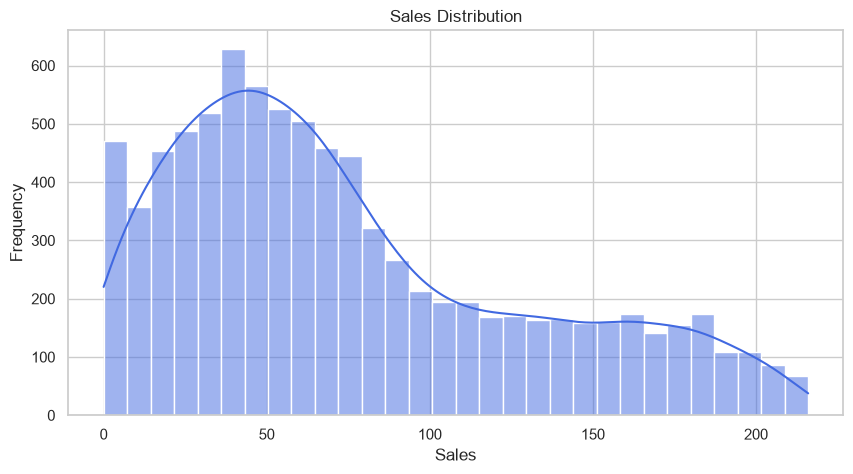

In [24]:
# ==============================================================================
# HISTOGRAM OF SALES
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Sales"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

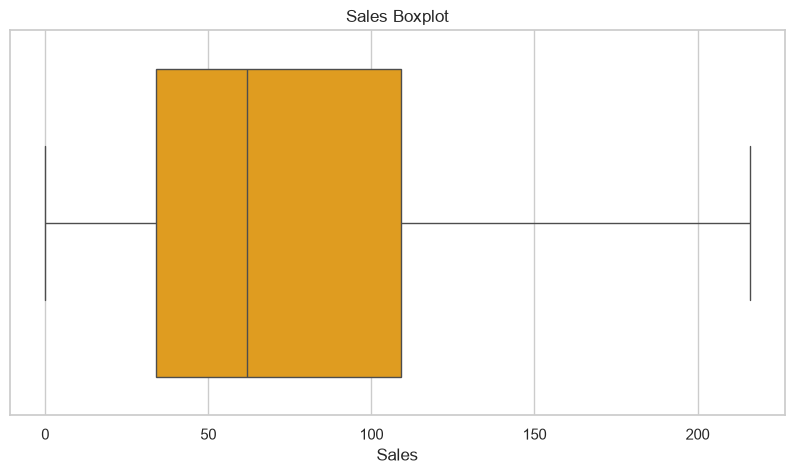

In [25]:
# ==============================================================================
# BOXPLOT OF SALES
# ==============================================================================

plt.figure(figsize=(10,5))

sns.boxplot(x=df["Sales"], color="orange")

plt.title("Sales Boxplot")

plt.show()

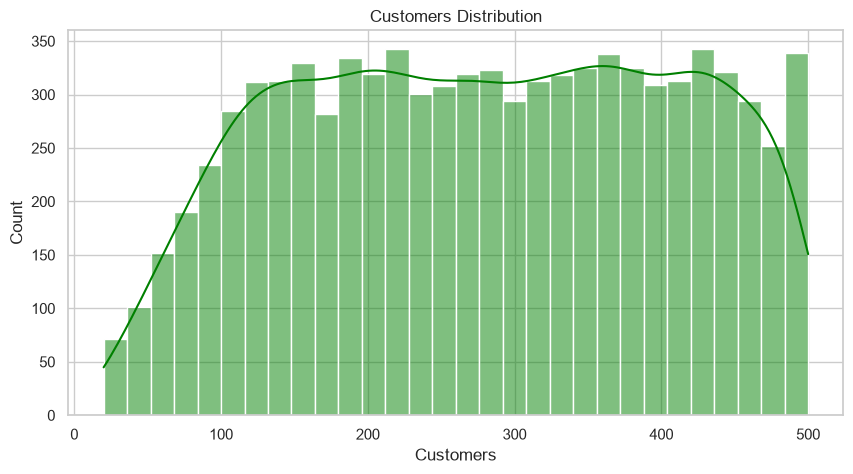

In [26]:
# ==============================================================================
# HISTOGRAM OF CUSTOMERS
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Customers"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Customers Distribution")

plt.show()

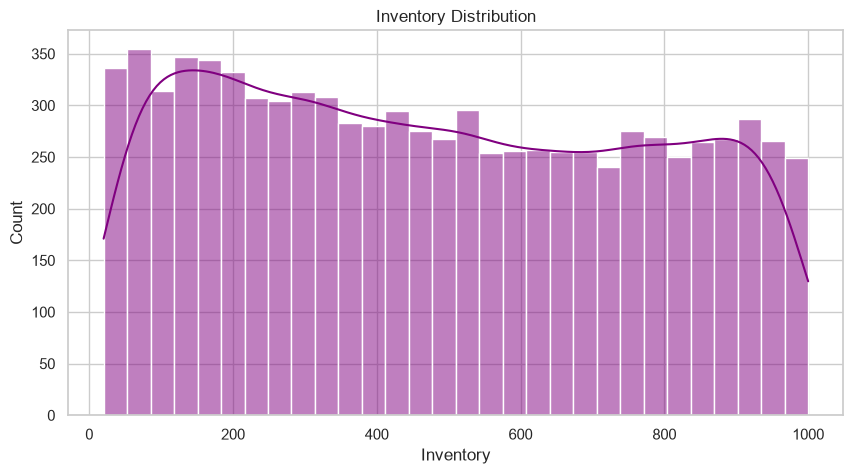

In [27]:
# ==============================================================================
# HISTOGRAM OF INVENTORY
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Inventory"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Inventory Distribution")

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

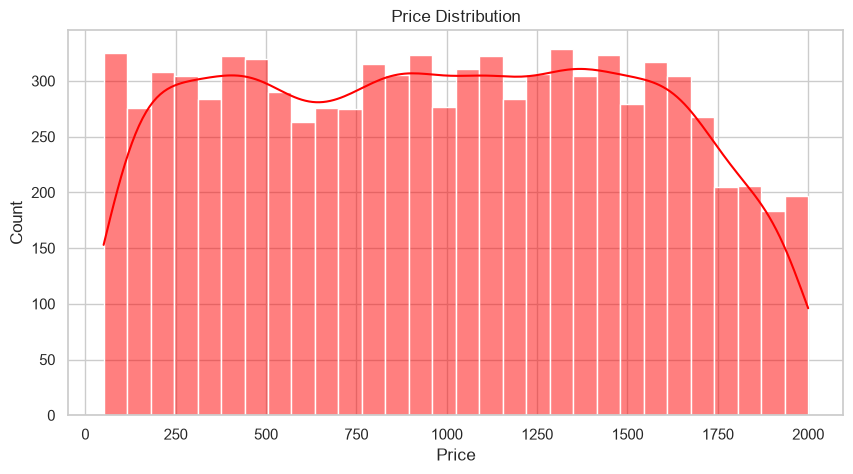

In [28]:
# ==============================================================================
# HISTOGRAM OF PRICE
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Price"],
    bins=30,
    kde=True,
    color="red"
)

plt.title("Price Distribution")

plt.show

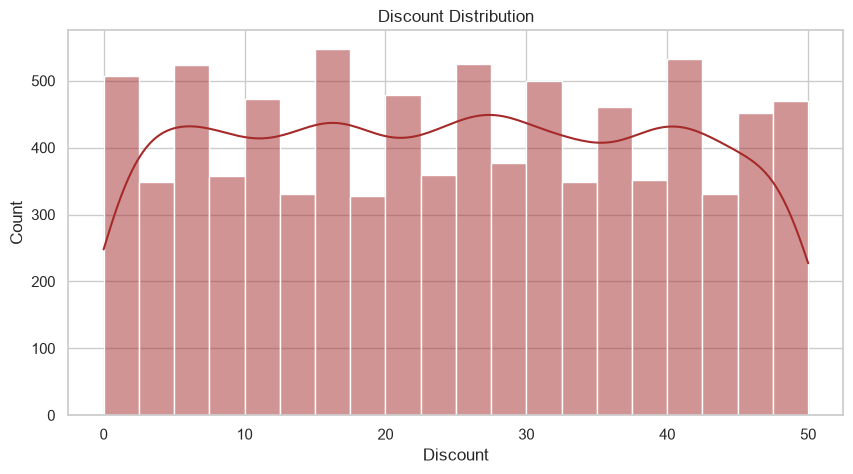

In [29]:
# ==============================================================================
# HISTOGRAM OF DISCOUNT
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Discount"],
    bins=20,
    kde=True,
    color="brown"
)

plt.title("Discount Distribution")

plt.show()

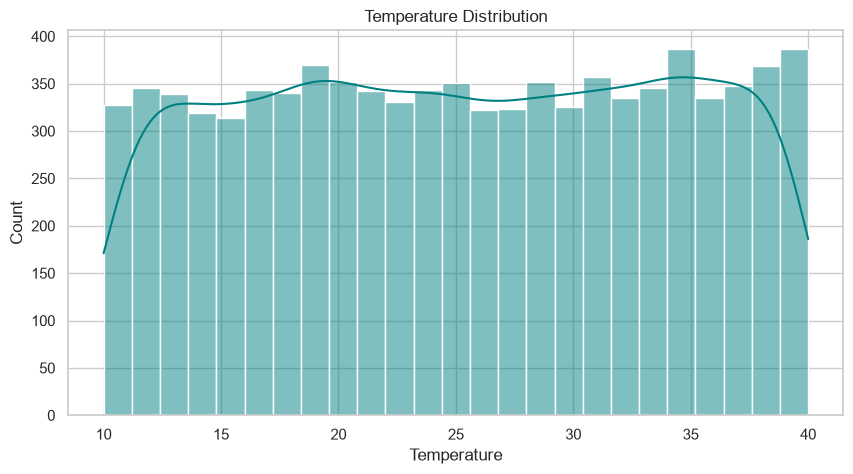

In [30]:
# ==============================================================================
# HISTOGRAM OF TEMPERATURE
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Temperature"],
    bins=25,
    kde=True,
    color="teal"
)

plt.title("Temperature Distribution")

plt.show()

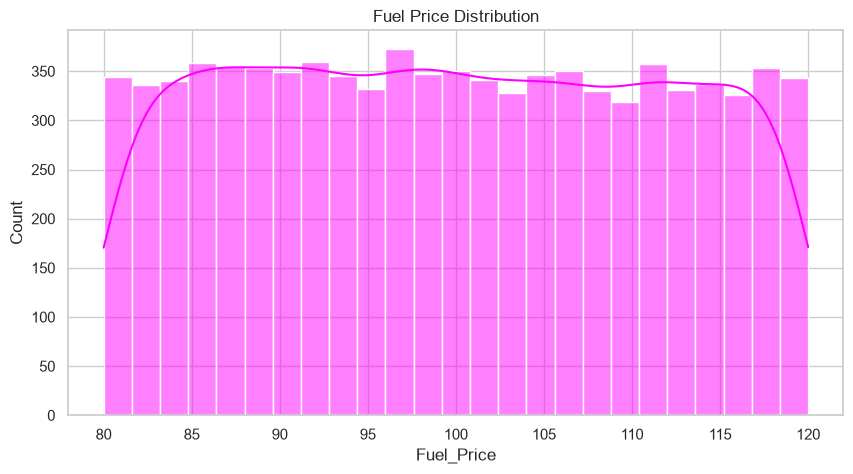

In [31]:
# ==============================================================================
# HISTOGRAM OF FUEL PRICE
# ==============================================================================

plt.figure(figsize=(10,5))

sns.histplot(
    df["Fuel_Price"],
    bins=25,
    kde=True,
    color="magenta"
)

plt.title("Fuel Price Distribution")

plt.show()

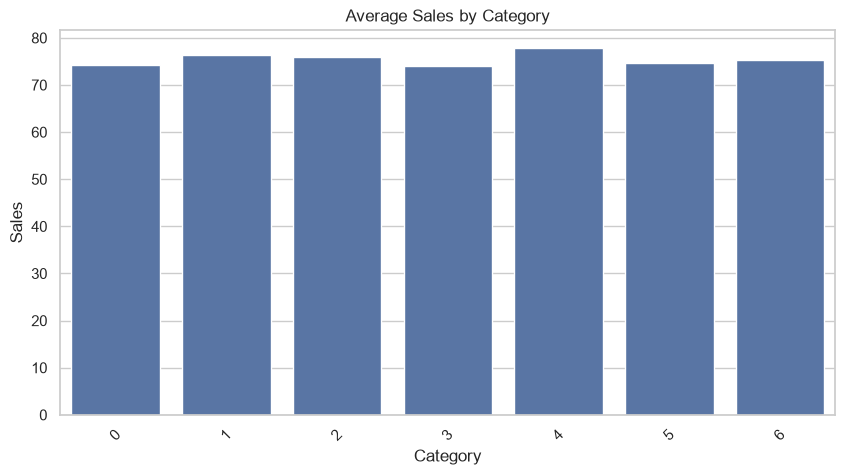

In [32]:
# ==============================================================================
# SALES BY CATEGORY
# ==============================================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator="mean",
    errorbar=None
)

plt.title("Average Sales by Category")

plt.xticks(rotation=45)

plt.show()

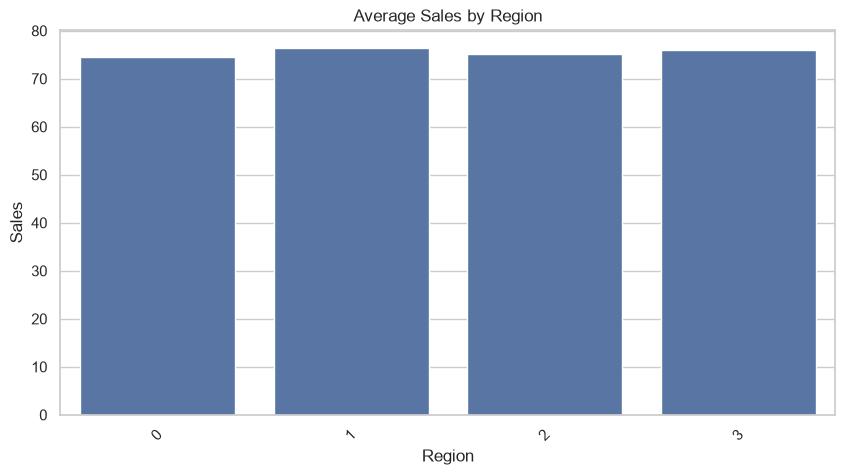

In [33]:
# ==============================================================================
# SALES BY REGION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="Sales",
    estimator="mean",
    errorbar=None
)

plt.title("Average Sales by Region")

plt.xticks(rotation=45)

plt.show()

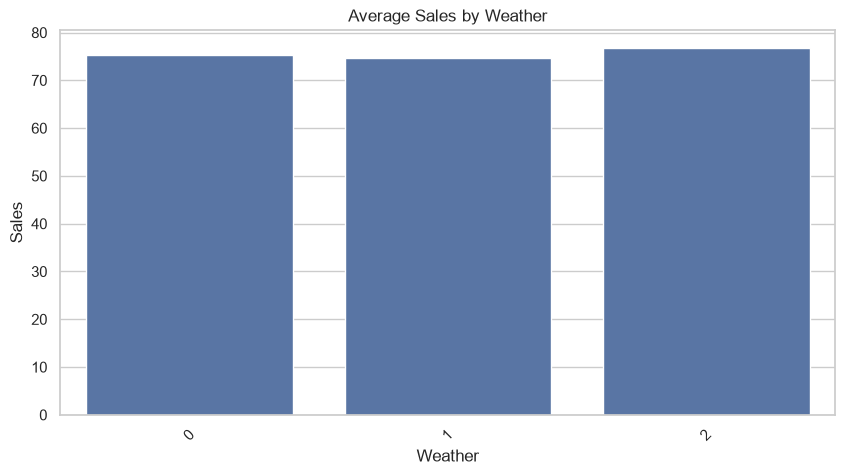

In [34]:
# ==============================================================================
# SALES BY WEATHER
# ==============================================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Weather",
    y="Sales",
    estimator="mean",
    errorbar=None
)

plt.title("Average Sales by Weather")

plt.xticks(rotation=45)

plt.show()

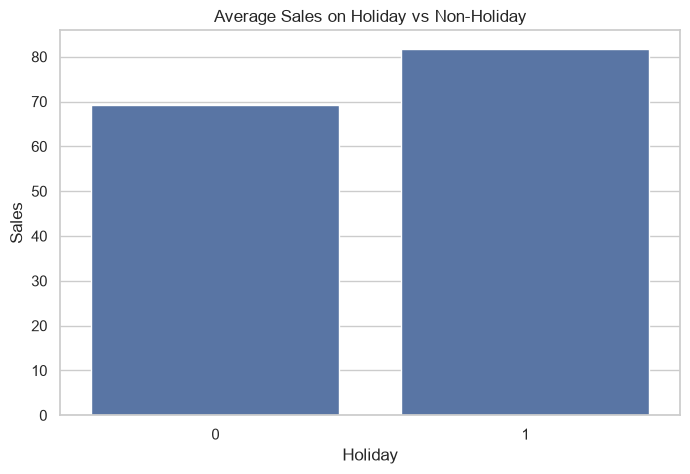

In [35]:
# ==============================================================================
# SALES BY HOLIDAY
# ==============================================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Holiday",
    y="Sales",
    estimator="mean",
    errorbar=None
)

plt.title("Average Sales on Holiday vs Non-Holiday")

plt.show()

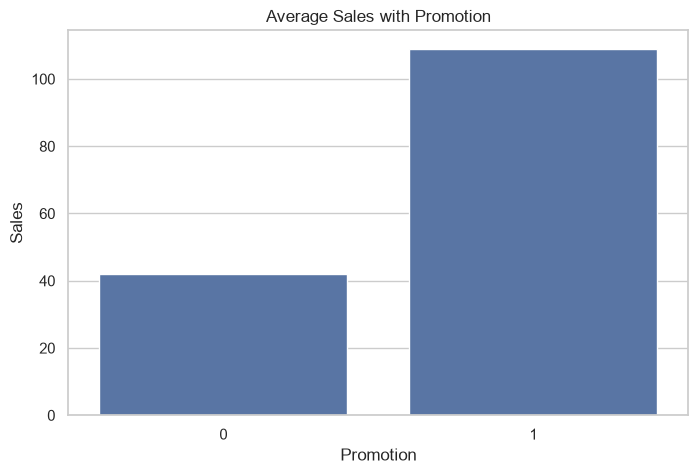

In [36]:
# ==============================================================================
# SALES BY PROMOTION
# ==============================================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Promotion",
    y="Sales",
    estimator="mean",
    errorbar=None
)

plt.title("Average Sales with Promotion")

plt.show()

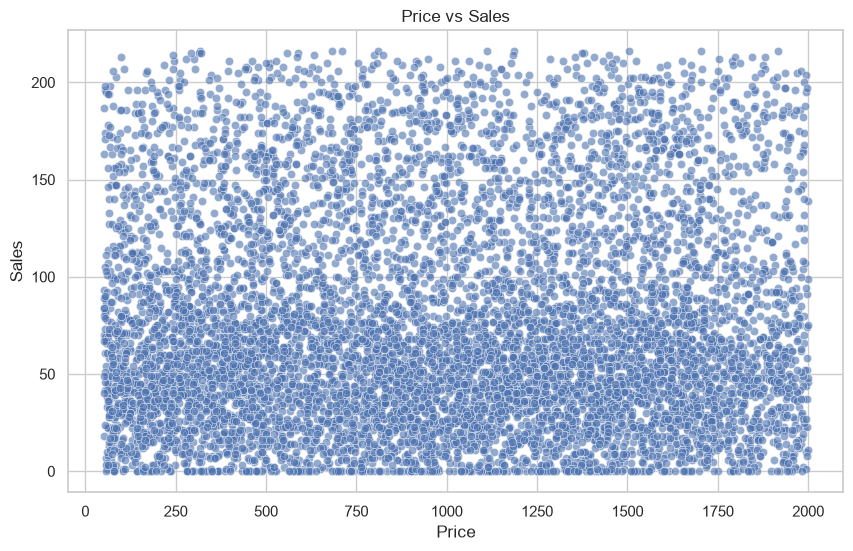

In [37]:
# ==============================================================================
# SALES VS PRICE
# ==============================================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Price",
    y="Sales",
    alpha=0.6
)

plt.title("Price vs Sales")

plt.show()

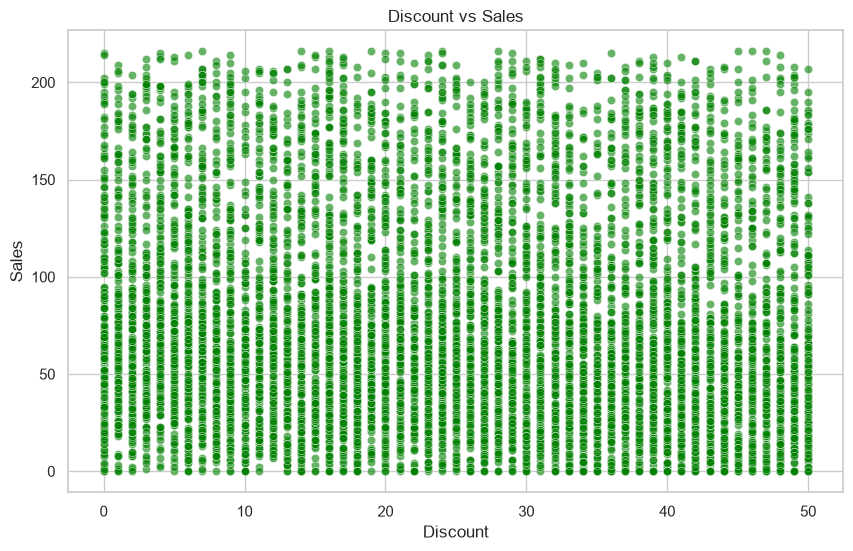

In [38]:
# ==============================================================================
# SALES VS DISCOUNT
# ==============================================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Sales",
    alpha=0.6,
    color="green"
)

plt.title("Discount vs Sales")

plt.show()

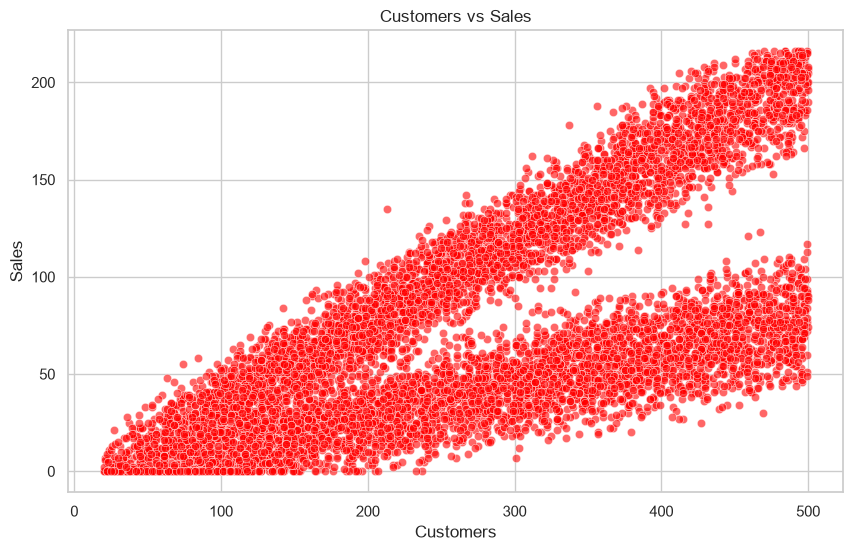

In [39]:
# ==============================================================================
# SALES VS CUSTOMERS
# ==============================================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Customers",
    y="Sales",
    alpha=0.6,
    color="red"
)

plt.title("Customers vs Sales")

plt.show()

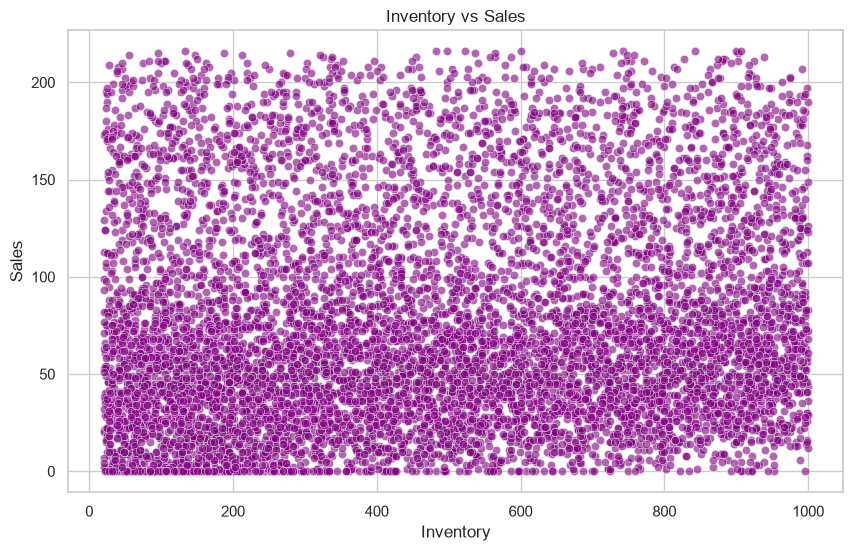

In [40]:
# ==============================================================================
# SALES VS INVENTORY
# ==============================================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Inventory",
    y="Sales",
    alpha=0.6,
    color="purple"
)

plt.title("Inventory vs Sales")

plt.show()

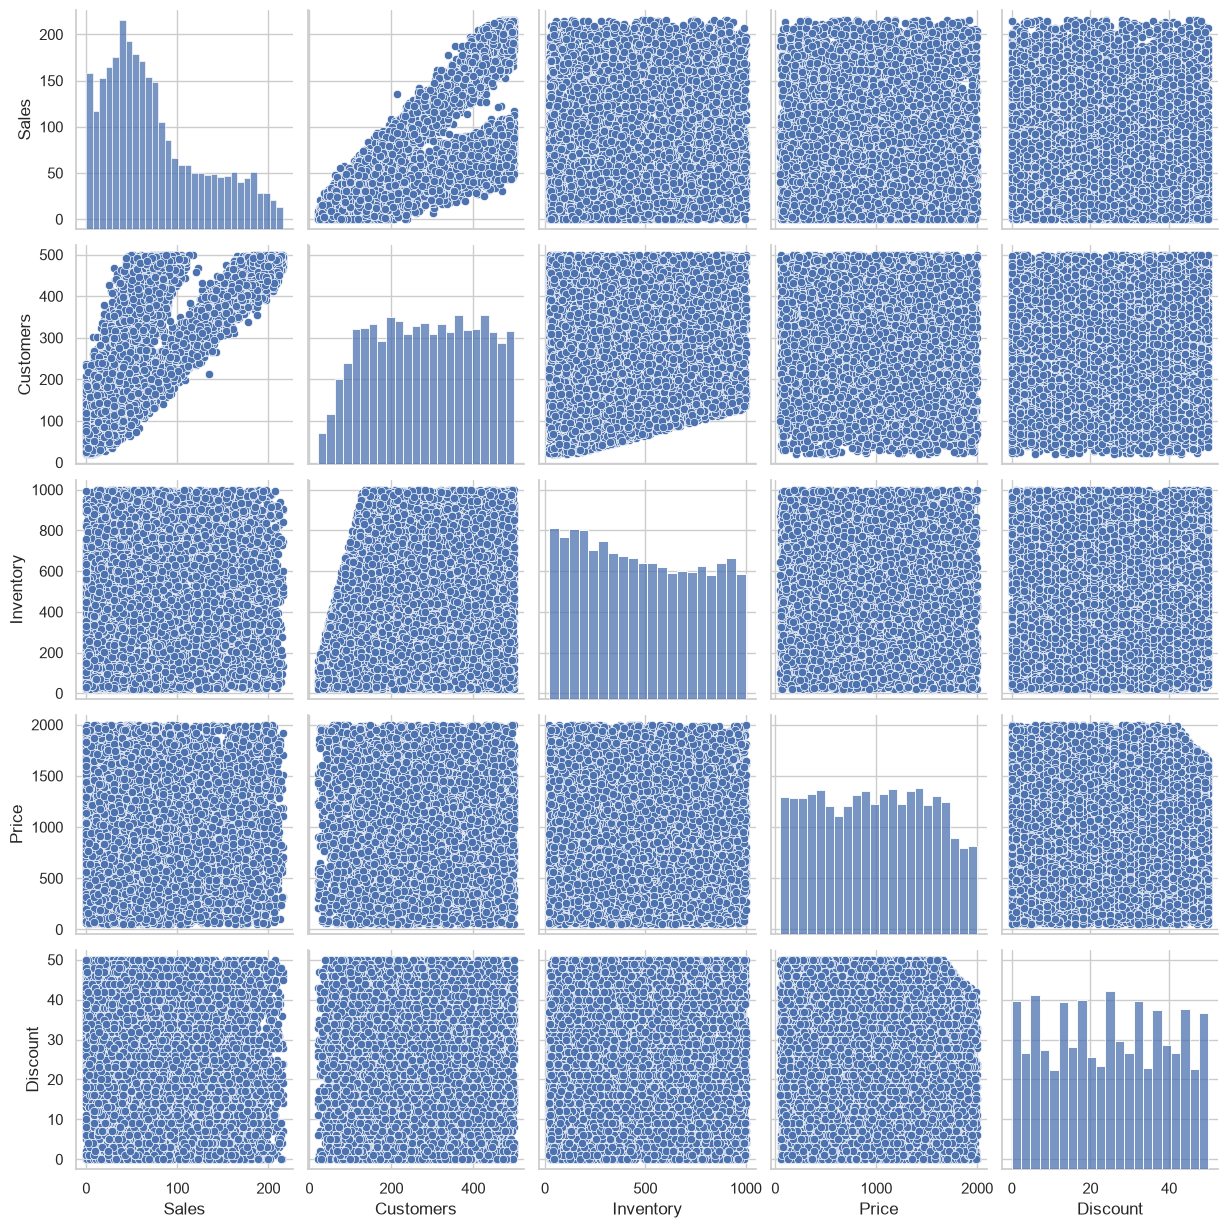

In [41]:
# ==============================================================================
# PAIRPLOT OF IMPORTANT FEATURES
# ==============================================================================

sns.pairplot(
    df[
        [
            "Sales",
            "Customers",
            "Inventory",
            "Price",
            "Discount"
        ]
    ]
)

plt.show()

In [42]:
# ==============================================================================
# CORRELATION MATRIX
# ==============================================================================

corr = df.corr(numeric_only=True)

corr

,Store_ID,Product_ID,Category,Region,Holiday,Promotion,Weather,Temperature,Fuel_Price,CPI,Unemployment,Inventory,Price,Competitor_Price,Discount,Customers,Sales,Year,Month,Day,Week,Quarter,Day_Name,Month_Name,Weekend,Season,Inventory_Per_Customer,Price_Difference,Discount_Amount,Final_Price,Sales_Per_Customer,Promotion_Impact
Store_ID,1.00,0.00,0.00,0.01,-0.00,-0.01,-0.00,-0.00,0.01,0.00,0.01,-0.01,0.01,0.01,-0.00,0.01,0.00,0.01,0.01,-0.00,0.01,0.01,-0.02,0.00,-0.01,-0.01,-0.02,0.01,0.00,0.01,-0.01,-0.01
Product_ID,0.00,1.00,0.02,0.00,0.00,-0.03,0.01,-0.02,-0.02,0.03,-0.00,0.00,0.01,0.01,-0.01,-0.01,-0.03,-0.01,-0.02,-0.00,-0.02,-0.01,0.00,0.00,-0.01,0.00,0.02,-0.02,-0.01,0.01,-0.02,-0.03
Category,0.00,0.02,1.00,0.02,-0.00,-0.00,-0.01,-0.01,0.02,-0.01,0.00,-0.01,-0.00,-0.00,0.01,0.01,0.00,-0.01,0.01,-0.01,0.01,0.01,0.01,0.01,0.01,-0.00,-0.02,-0.01,-0.00,-0.00,-0.00,-0.00
Region,0.01,0.00,0.02,1.00,0.00,0.00,-0.02,-0.03,-0.01,-0.02,0.01,-0.00,-0.01,-0.01,-0.01,0.00,0.01,-0.00,-0.00,-0.01,-0.00,0.00,0.00,0.01,-0.01,-0.02,0.00,-0.02,-0.01,-0.00,-0.00,-0.00
Holiday,-0.00,0.00,-0.00,0.00,1.00,-0.01,0.00,0.00,0.01,0.01,-0.01,-0.00,-0.00,-0.01,0.00,-0.01,0.11,0.00,-0.00,-0.00,-0.00,-0.01,-0.02,0.00,0.01,0.00,0.01,0.00,-0.00,-0.00,0.16,-0.01
Promotion,-0.01,-0.03,-0.00,0.00,-0.01,1.00,0.00,0.01,-0.00,-0.02,-0.02,0.00,0.01,0.01,-0.00,-0.03,0.62,0.01,0.01,-0.01,0.01,0.00,-0.00,0.00,0.00,-0.00,0.03,-0.00,0.00,0.01,0.87,0.77
Weather,-0.00,0.01,-0.01,-0.02,0.00,0.00,1.00,0.01,0.01,0.01,0.00,0.01,0.00,0.00,0.00,0.01,0.01,0.01,0.00,0.02,0.00,-0.00,0.01,-0.02,-0.01,0.00,0.00,0.00,0.01,0.00,0.00,-0.00
Temperature,-0.00,-0.02,-0.01,-0.03,0.00,0.01,0.01,1.00,0.02,0.01,-0.00,-0.01,-0.01,-0.01,-0.01,0.02,0.02,-0.01,-0.00,-0.01,-0.00,-0.01,-0.02,-0.01,0.01,0.02,-0.02,-0.00,-0.01,-0.01,0.01,0.01
Fuel_Price,0.01,-0.02,0.02,-0.01,0.01,-0.00,0.01,0.02,1.00,-0.01,0.01,-0.02,-0.00,-0.01,-0.00,0.00,-0.00,-0.01,-0.01,-0.00,-0.01,-0.01,0.01,-0.00,-0.01,0.00,-0.02,0.01,0.00,-0.01,-0.01,-0.00
CPI,0.00,0.03,-0.01,-0.02,0.01,-0.02,0.01,0.01,-0.01,1.00,-0.01,-0.01,-0.03,-0.03,-0.01,-0.02,-0.02,0.02,-0.01,-0.00,-0.01,-0.01,0.00,0.01,-0.02,0.00,0.00,0.02,-0.02,-0.03,-0.01,-0.02


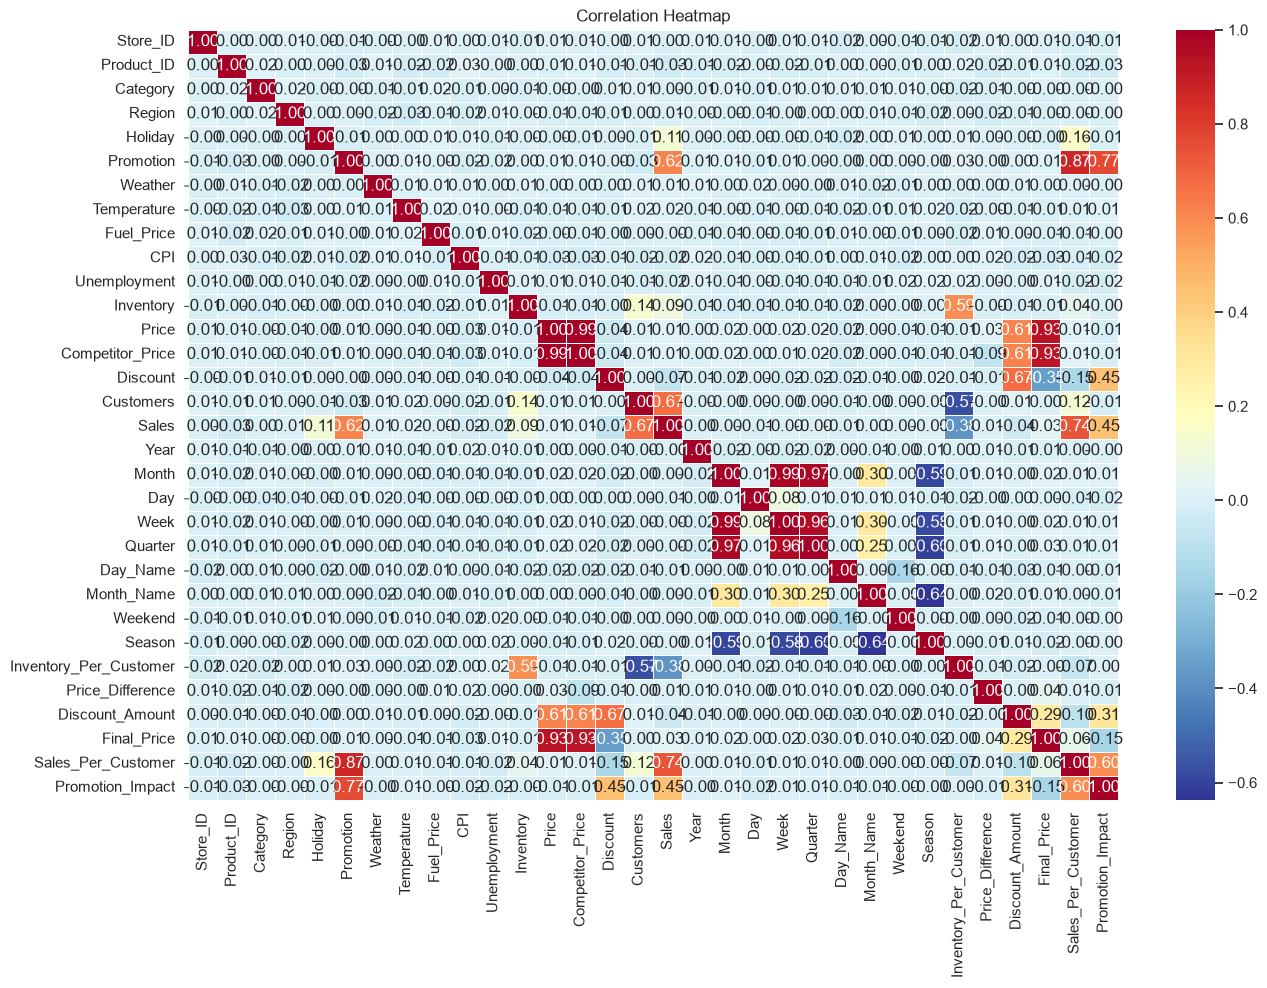

In [43]:
# ==============================================================================
# CORRELATION HEATMAP
# ==============================================================================

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [44]:
# ==============================================================================
# SALES CORRELATION
# ==============================================================================

corr["Sales"].sort_values(ascending=False)

Sales                     1.00
Sales_Per_Customer        0.74
Customers                 0.67
Promotion                 0.62
Promotion_Impact          0.45
Holiday                   0.11
Inventory                 0.09
Final_Price               0.03
Temperature               0.02
Price                     0.01
Competitor_Price          0.01
Weather                   0.01
Region                    0.01
Price_Difference          0.01
Month_Name                0.00
Weekend                   0.00
Category                  0.00
Store_ID                  0.00
Month                     0.00
Quarter                  -0.00
Season                   -0.00
Week                     -0.00
Year                     -0.00
Fuel_Price               -0.00
Day_Name                 -0.01
Day                      -0.01
CPI                      -0.02
Unemployment             -0.02
Product_ID               -0.03
Discount_Amount          -0.04
Discount                 -0.07
Inventory_Per_Customer   -0.38
Name: Sa

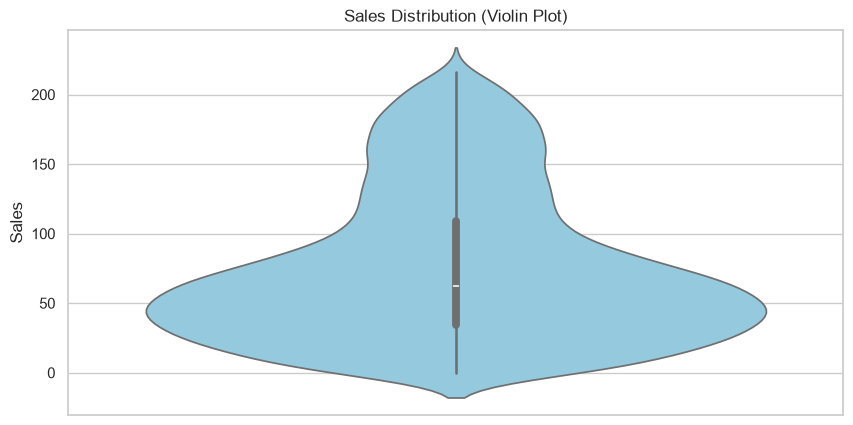

In [45]:
# ==============================================================================
# VIOLIN PLOT - SALES
# ==============================================================================

plt.figure(figsize=(10,5))

sns.violinplot(y=df["Sales"], color="skyblue")

plt.title("Sales Distribution (Violin Plot)")

plt.show()

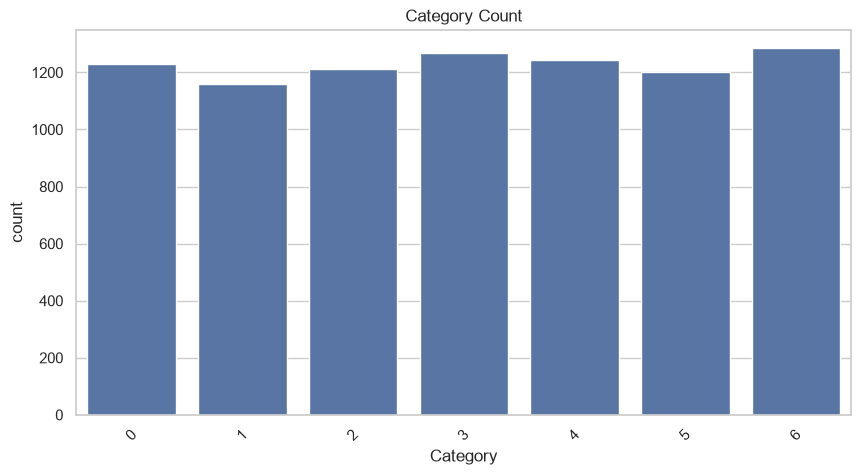

In [46]:
# ==============================================================================
# COUNTPLOT - CATEGORY
# ==============================================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Category"
)

plt.xticks(rotation=45)

plt.title("Category Count")

plt.show()

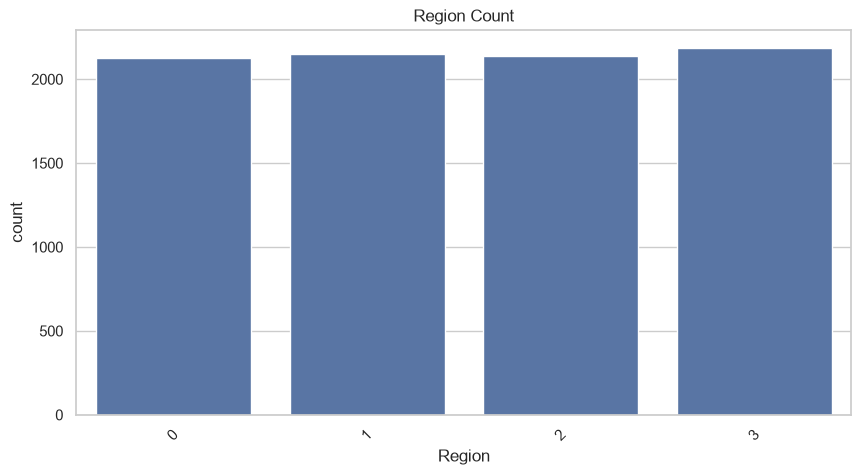

In [47]:
# ==============================================================================
# COUNTPLOT - REGION
# ==============================================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Region"
)

plt.xticks(rotation=45)

plt.title("Region Count")

plt.show()

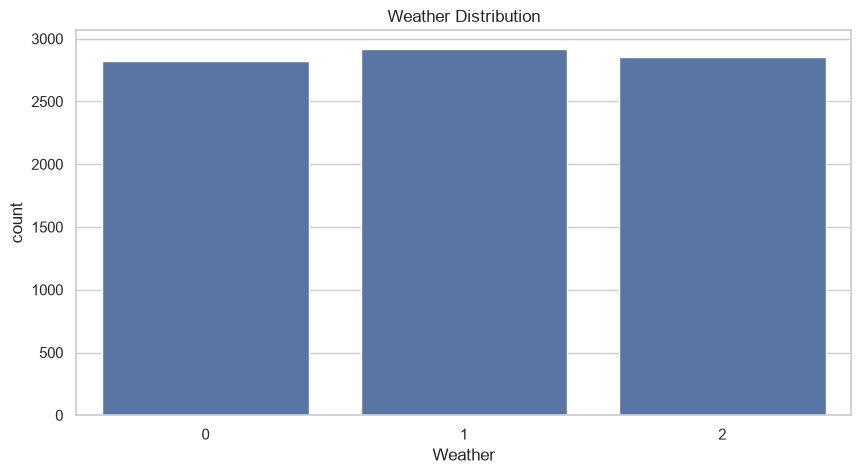

In [48]:
# ==============================================================================
# COUNTPLOT - WEATHER
# ==============================================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Weather"
)

plt.title("Weather Distribution")

plt.show()

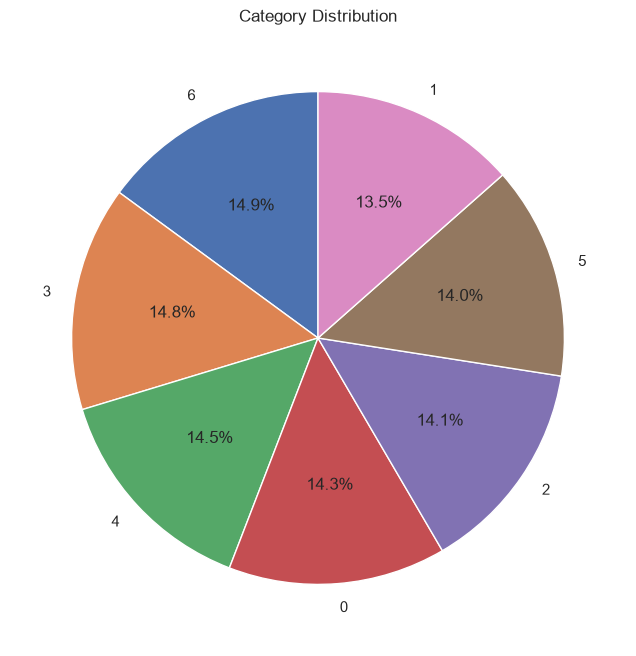

In [49]:
# ==============================================================================
# PIE CHART - CATEGORY
# ==============================================================================

category_count = df["Category"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    category_count,
    labels=category_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Category Distribution")

plt.show()

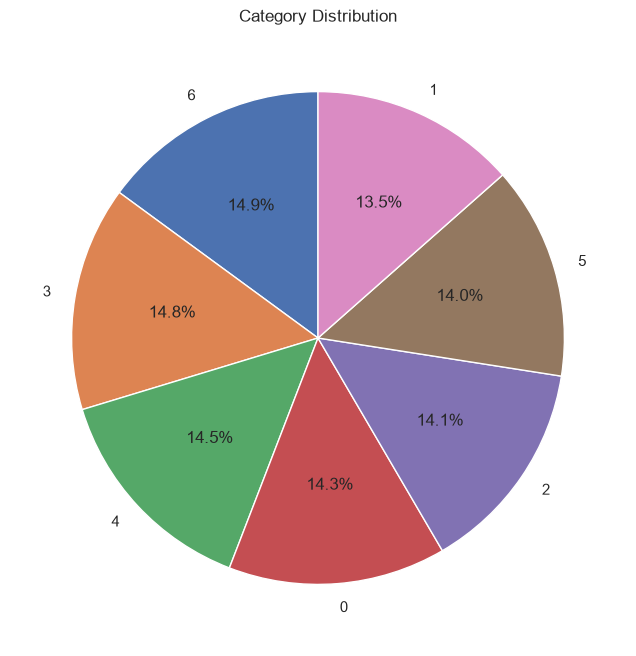

In [50]:
# ==============================================================================
# PIE CHART - CATEGORY
# ==============================================================================

category_count = df["Category"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    category_count,
    labels=category_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Category Distribution")

plt.show()

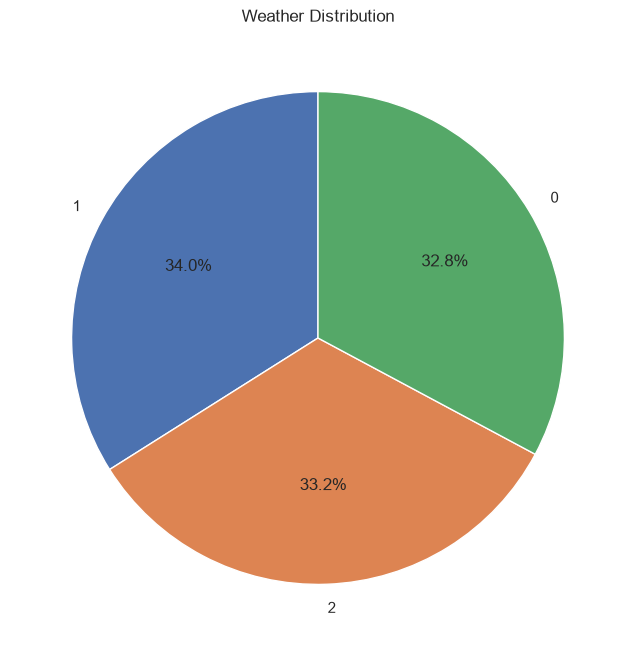

In [51]:
# ==============================================================================
# PIE CHART - WEATHER
# ==============================================================================

weather_count = df["Weather"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    weather_count,
    labels=weather_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Weather Distribution")

plt.show()

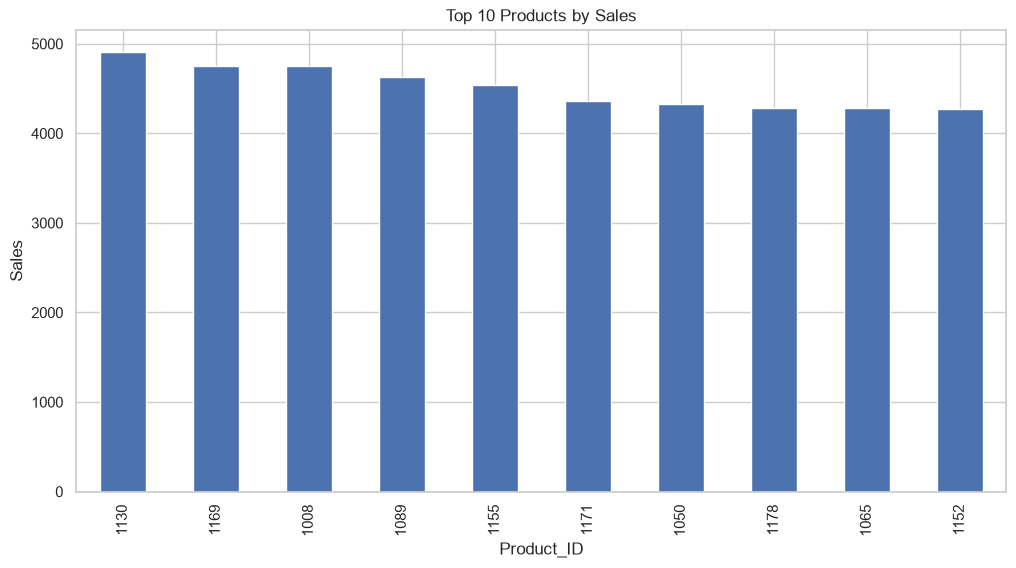

In [52]:
# ==============================================================================
# TOP 10 PRODUCTS BY SALES
# ==============================================================================

top_products = (
    df.groupby("Product_ID")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales")

plt.ylabel("Sales")

plt.show()

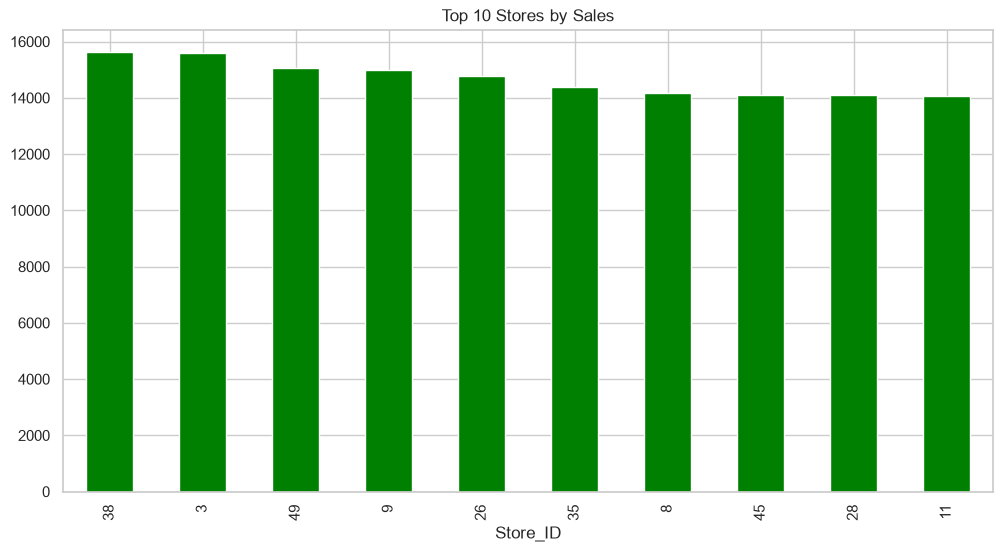

In [53]:
# ==============================================================================
# TOP 10 STORES BY SALES
# ==============================================================================

top_store = (
    df.groupby("Store_ID")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_store.plot(kind="bar", color="green")

plt.title("Top 10 Stores by Sales")

plt.show()

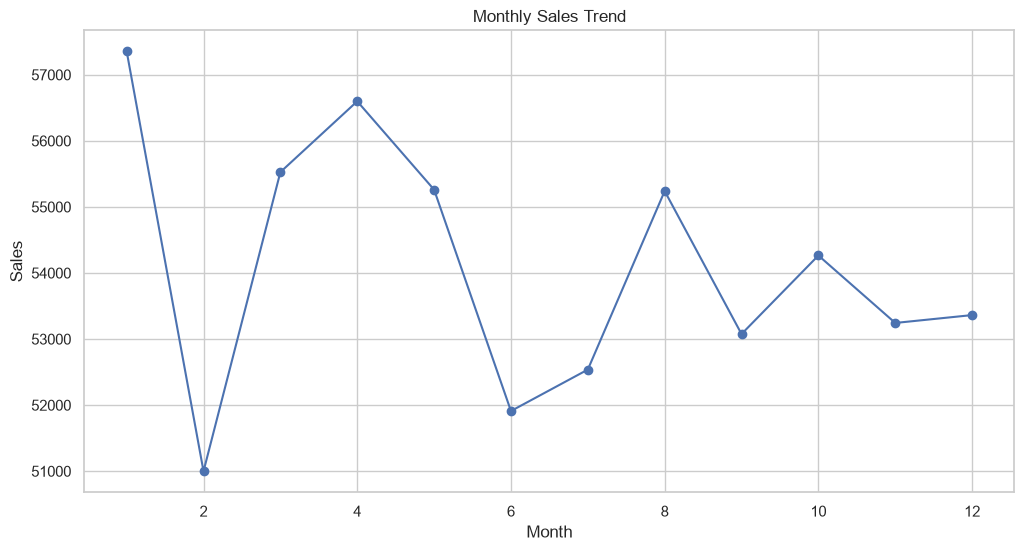

In [54]:
# ==============================================================================
# MONTHLY SALES TREND
# ==============================================================================

monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

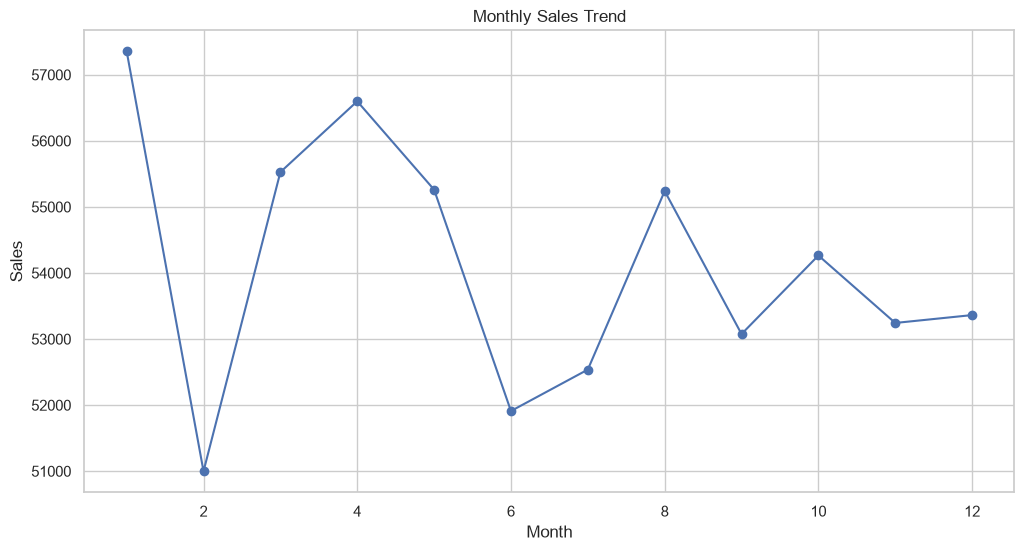

In [55]:
# ==============================================================================
# MONTHLY SALES TREND
# ==============================================================================

monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

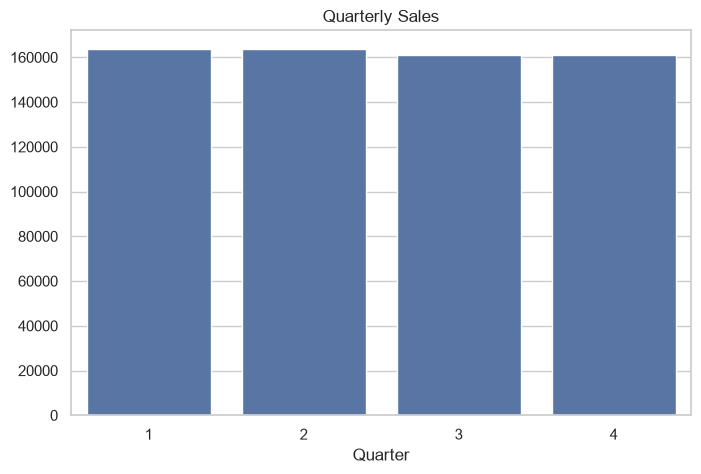

In [56]:
# ==============================================================================
# QUARTERLY SALES
# ==============================================================================

quarter_sales = (
    df.groupby("Quarter")["Sales"]
      .sum()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=quarter_sales.index,
    y=quarter_sales.values
)

plt.title("Quarterly Sales")

plt.show()

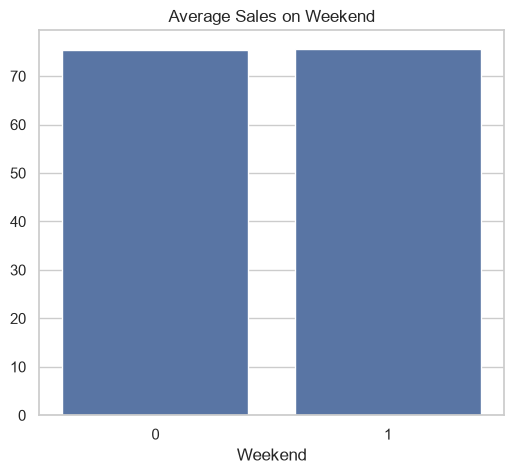

In [57]:
# ==============================================================================
# SALES BY WEEKEND
# ==============================================================================

weekend_sales = (
    df.groupby("Weekend")["Sales"]
      .mean()
)

plt.figure(figsize=(6,5))

sns.barplot(
    x=weekend_sales.index,
    y=weekend_sales.values
)

plt.title("Average Sales on Weekend")

plt.show()

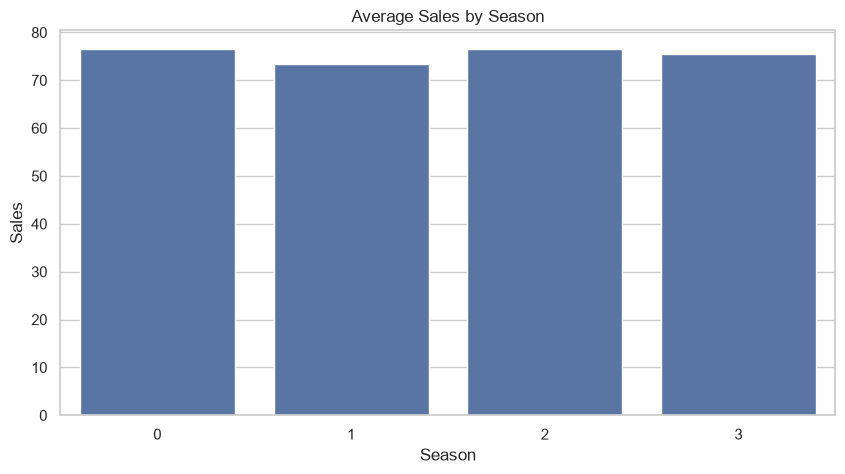

In [58]:
# ==============================================================================
# SALES BY SEASON
# ==============================================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Season",
    y="Sales",
    estimator="mean",
    errorbar=None
)

plt.title("Average Sales by Season")

plt.show()

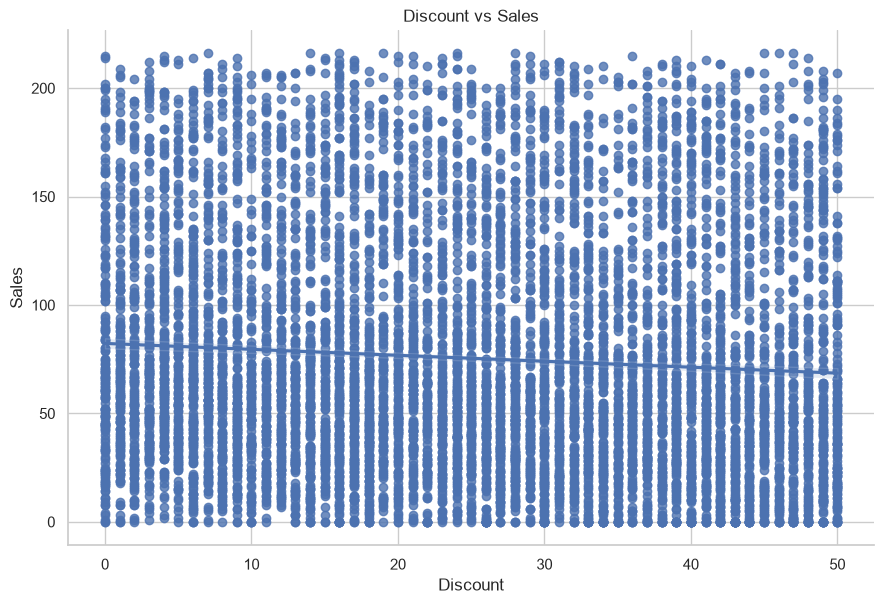

In [59]:
# ==============================================================================
# DISCOUNT VS SALES
# ==============================================================================

sns.lmplot(
    data=df,
    x="Discount",
    y="Sales",
    height=6,
    aspect=1.5
)

plt.title("Discount vs Sales")

plt.show()

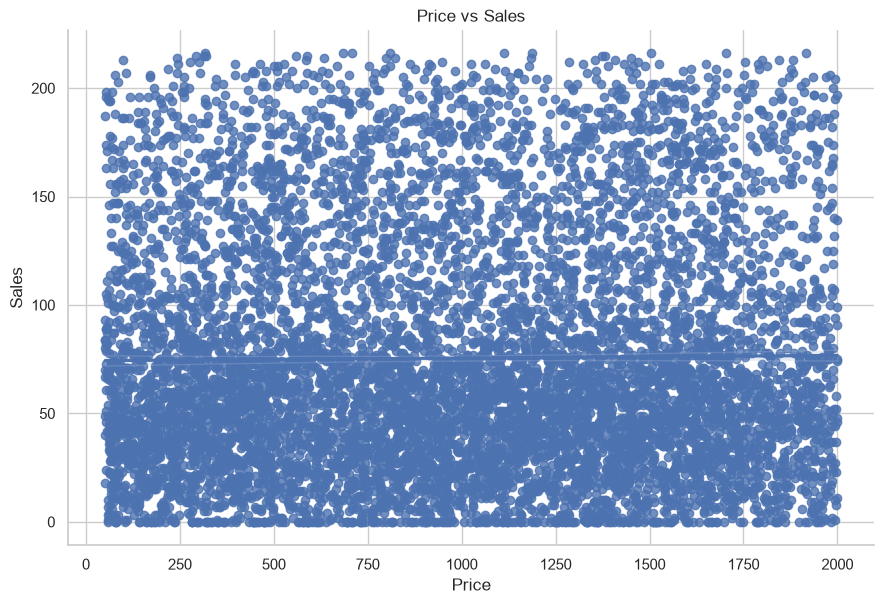

In [60]:
# ==============================================================================
# PRICE VS SALES
# ==============================================================================

sns.lmplot(
    data=df,
    x="Price",
    y="Sales",
    height=6,
    aspect=1.5
)

plt.title("Price vs Sales")

plt.show()

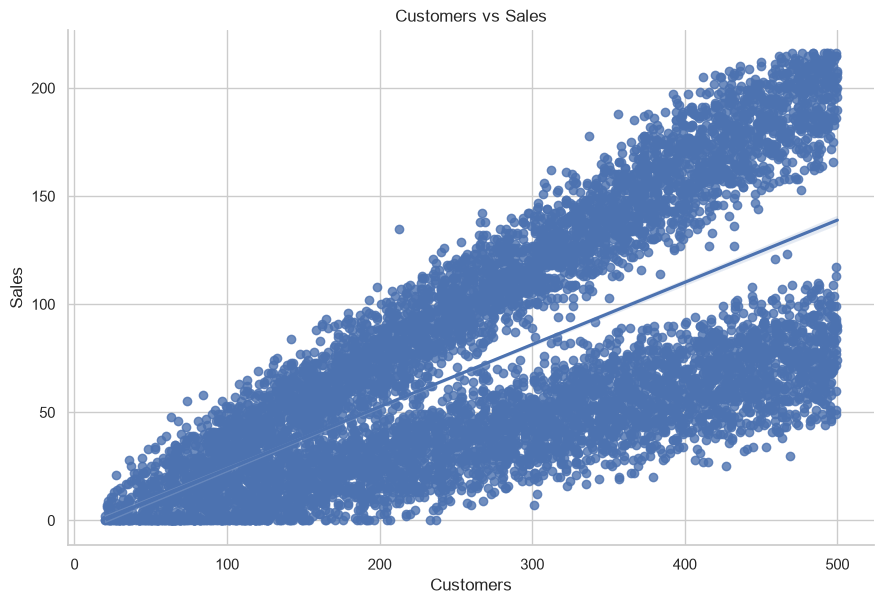

In [61]:
# ==============================================================================
# CUSTOMERS VS SALES
# ==============================================================================

sns.lmplot(
    data=df,
    x="Customers",
    y="Sales",
    height=6,
    aspect=1.5
)

plt.title("Customers vs Sales")

plt.show()

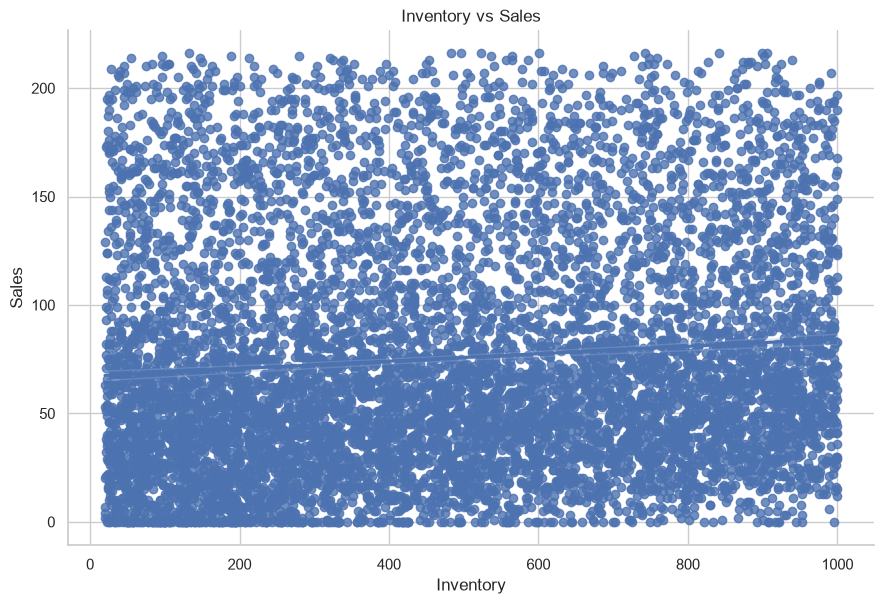

In [62]:
# ==============================================================================
# INVENTORY VS SALES
# ==============================================================================

sns.lmplot(
    data=df,
    x="Inventory",
    y="Sales",
    height=6,
    aspect=1.5
)

plt.title("Inventory vs Sales")

plt.show()

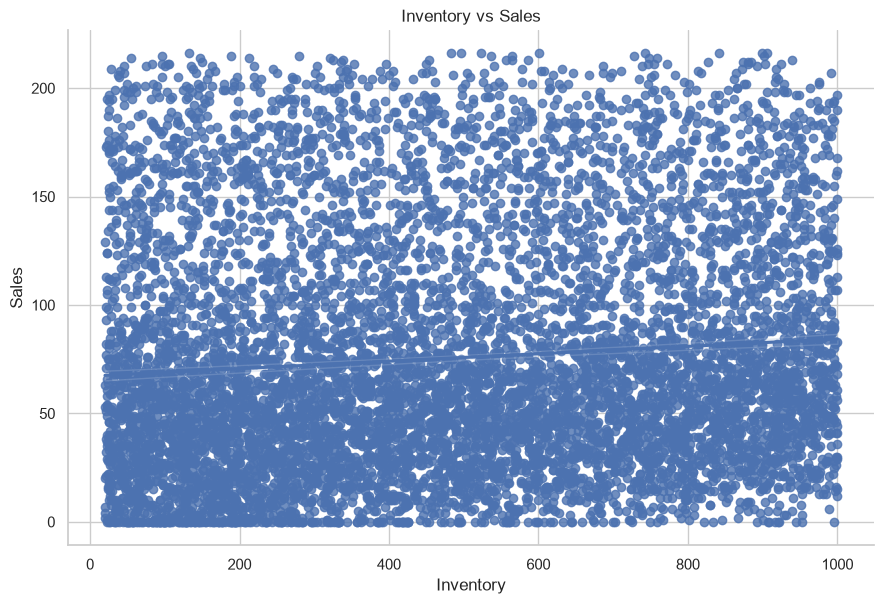

In [63]:
# ==============================================================================
# INVENTORY VS SALES
# ==============================================================================

sns.lmplot(
    data=df,
    x="Inventory",
    y="Sales",
    height=6,
    aspect=1.5
)

plt.title("Inventory vs Sales")

plt.show()

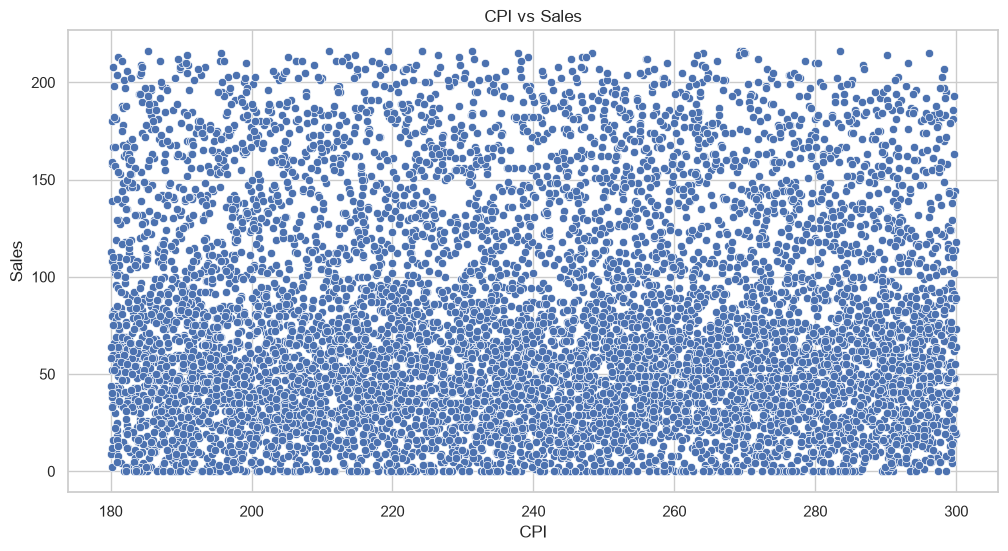

In [64]:
# ==============================================================================
# CPI VS SALES
# ==============================================================================

sns.scatterplot(
    data=df,
    x="CPI",
    y="Sales"
)

plt.title("CPI vs Sales")

plt.show()

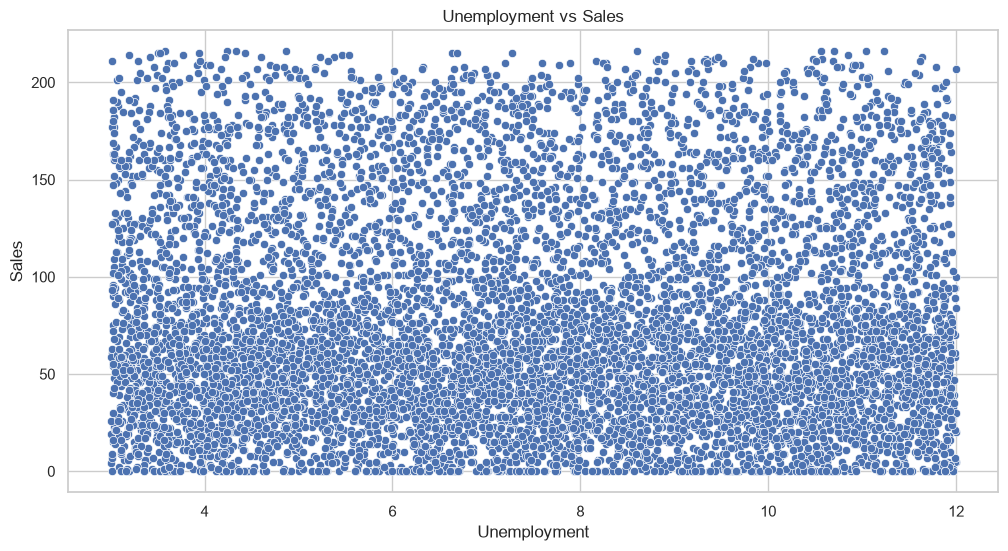

In [65]:
# ==============================================================================
# UNEMPLOYMENT VS SALES
# ==============================================================================

sns.scatterplot(
    data=df,
    x="Unemployment",
    y="Sales"
)

plt.title("Unemployment vs Sales")

plt.show()

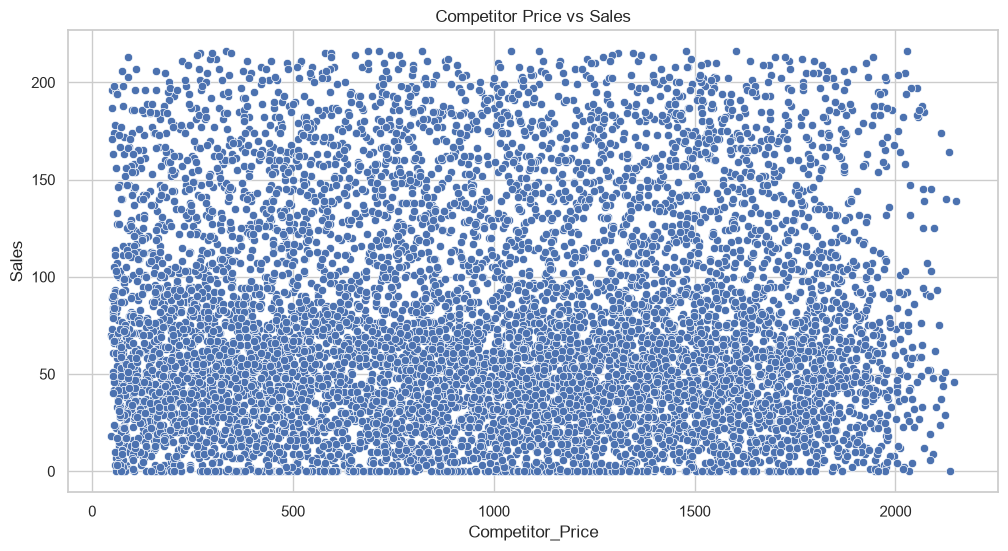

In [66]:
# ==============================================================================
# COMPETITOR PRICE VS SALES
# ==============================================================================

sns.scatterplot(
    data=df,
    x="Competitor_Price",
    y="Sales"
)

plt.title("Competitor Price vs Sales")

plt.show()

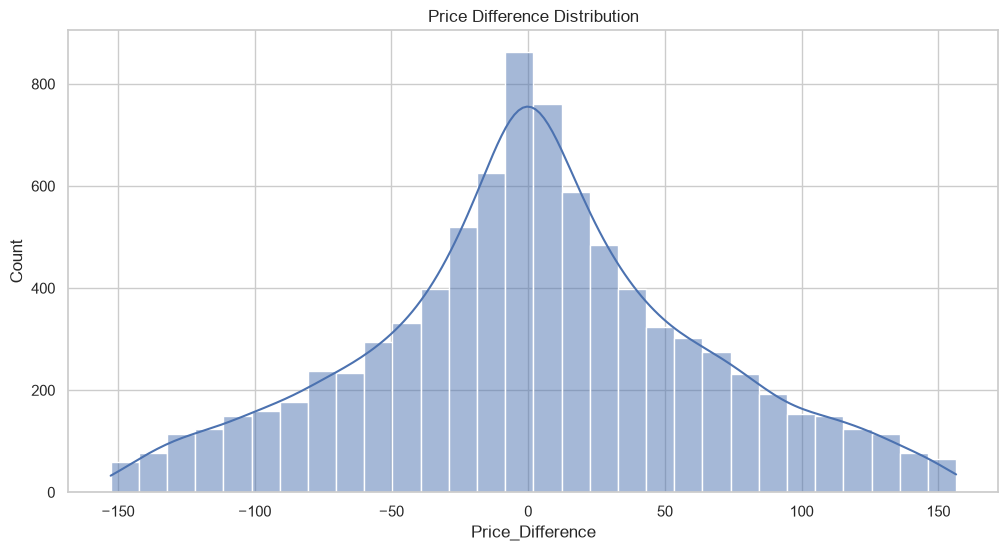

In [67]:
# ==============================================================================
# PRICE DIFFERENCE DISTRIBUTION
# ==============================================================================

sns.histplot(
    df["Price_Difference"],
    bins=30,
    kde=True
)

plt.title("Price Difference Distribution")

plt.show()

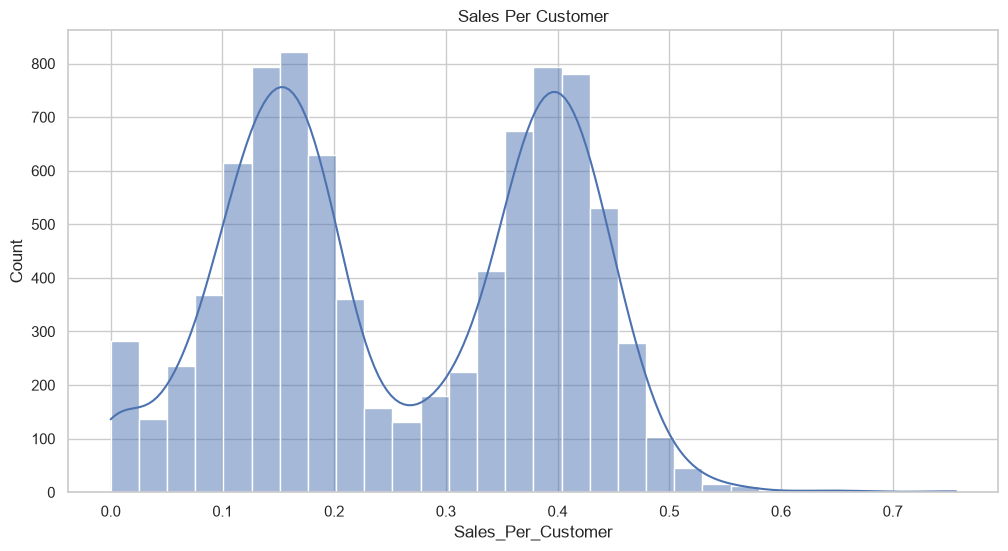

In [68]:
# ==============================================================================
# SALES PER CUSTOMER DISTRIBUTION
# ==============================================================================

sns.histplot(
    df["Sales_Per_Customer"],
    bins=30,
    kde=True
)

plt.title("Sales Per Customer")

plt.show()

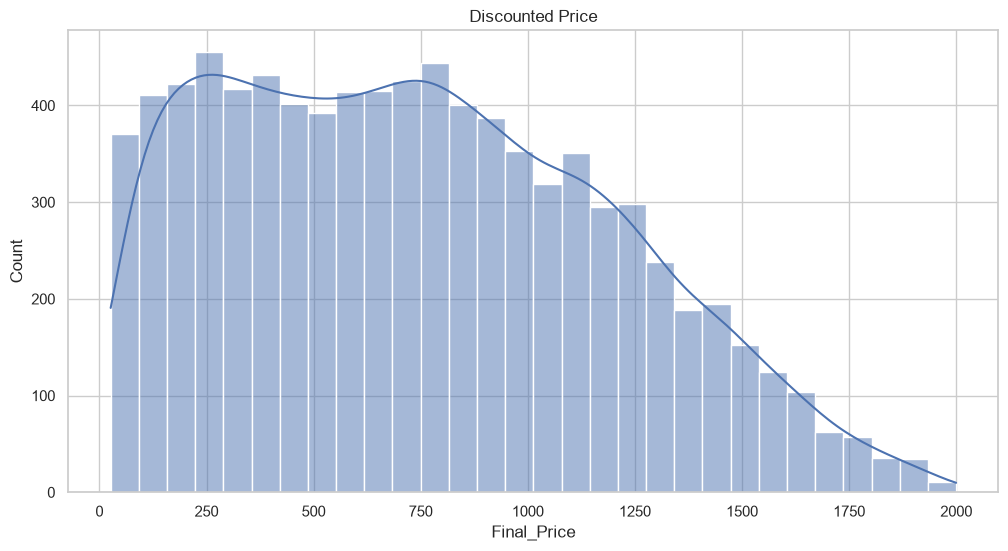

In [69]:
# ==============================================================================
# DISCOUNTED PRICE DISTRIBUTION
# ==============================================================================

sns.histplot(
    df["Final_Price"],
    bins=30,
    kde=True
)

plt.title("Discounted Price")

plt.show()

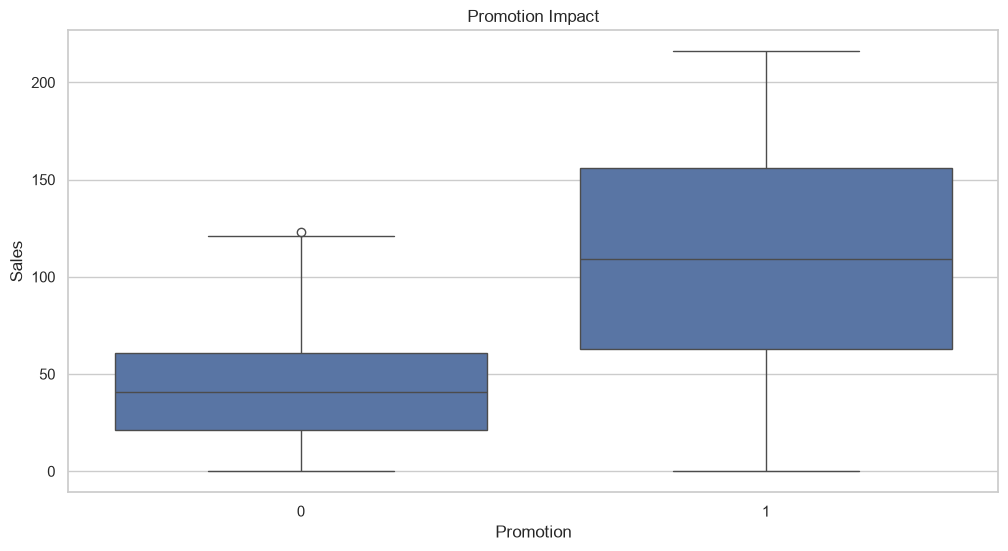

In [70]:
# ==============================================================================
# PROMOTION IMPACT
# ==============================================================================

sns.boxplot(
    data=df,
    x="Promotion",
    y="Sales"
)

plt.title("Promotion Impact")

plt.show()

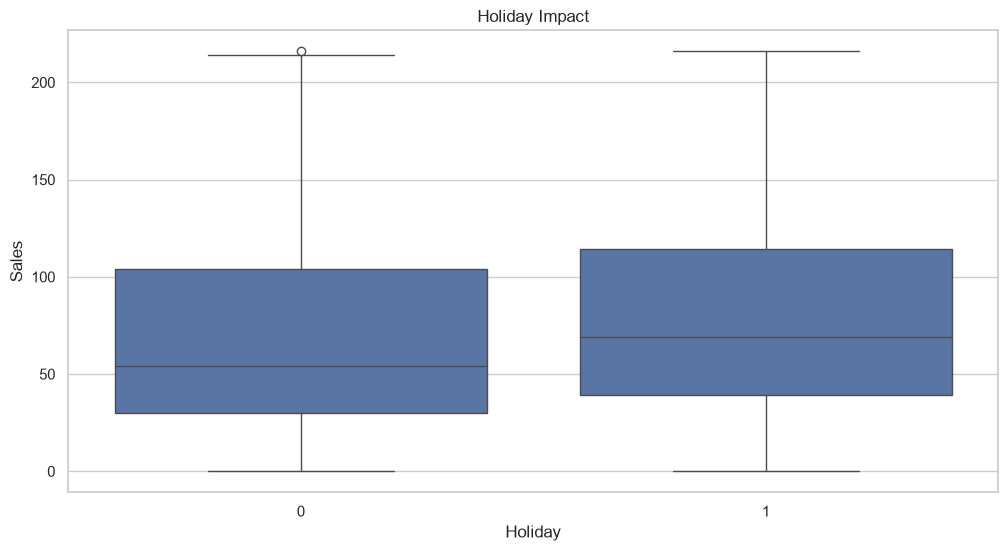

In [71]:
# ==============================================================================
# HOLIDAY IMPACT
# ==============================================================================

sns.boxplot(
    data=df,
    x="Holiday",
    y="Sales"
)

plt.title("Holiday Impact")

plt.show()

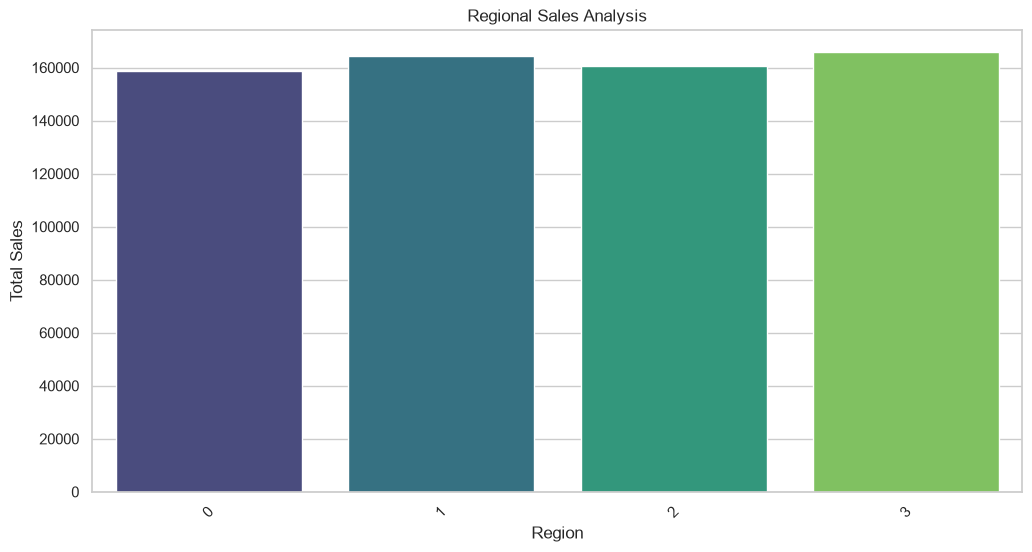

In [73]:
# ==============================================================================
# REGIONAL SALES ANALYSIS
# ==============================================================================

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    palette="viridis"
)

plt.title("Regional Sales Analysis")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

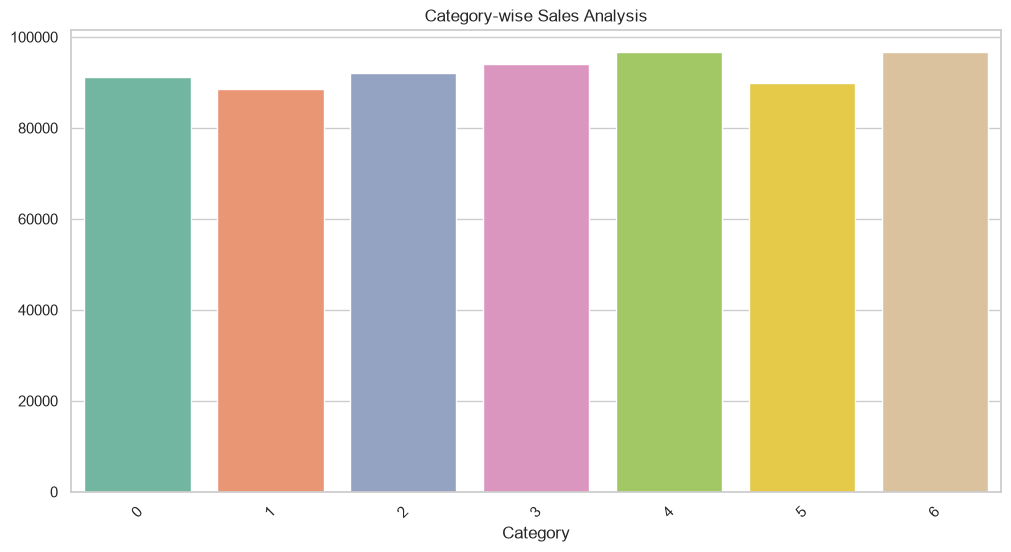

In [74]:
# ==============================================================================
# CATEGORY SALES ANALYSIS
# ==============================================================================

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="Set2"
)

plt.title("Category-wise Sales Analysis")

plt.xticks(rotation=45)

plt.show()

In [75]:
# ==============================================================================
# PRODUCT ANALYSIS
# ==============================================================================

product_sales = (
    df.groupby("Product_ID")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(product_sales.head(20))

Product_ID
1130    4913
1169    4753
1008    4751
1089    4635
1155    4540
1171    4358
1050    4323
1178    4280
1065    4279
1152    4268
1016    4265
1102    4234
1177    4208
1092    4176
1024    4127
1190    4100
1059    4099
1019    4081
1105    4062
1127    4061
Name: Sales, dtype: int64


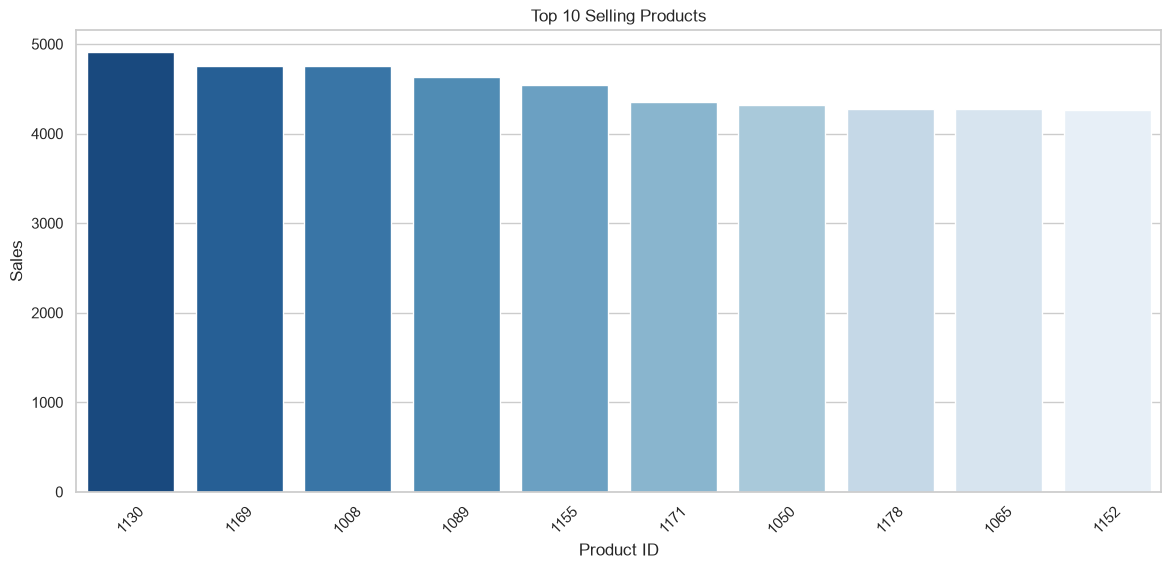

In [76]:
# ==============================================================================
# TOP 10 SELLING PRODUCTS
# ==============================================================================

top_products = product_sales.head(10)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_products.index.astype(str),
    y=top_products.values,
    palette="Blues_r"
)

plt.title("Top 10 Selling Products")

plt.xlabel("Product ID")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

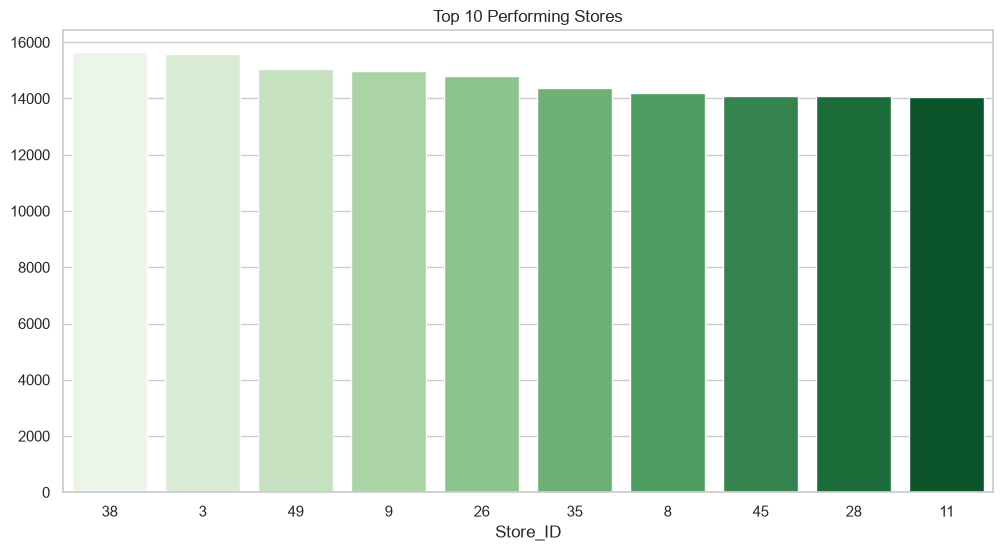

In [77]:
# ==============================================================================
# TOP 10 PERFORMING STORES
# ==============================================================================

top_store = (
    df.groupby("Store_ID")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_store.index.astype(str),
    y=top_store.values,
    palette="Greens"
)

plt.title("Top 10 Performing Stores")

plt.show()

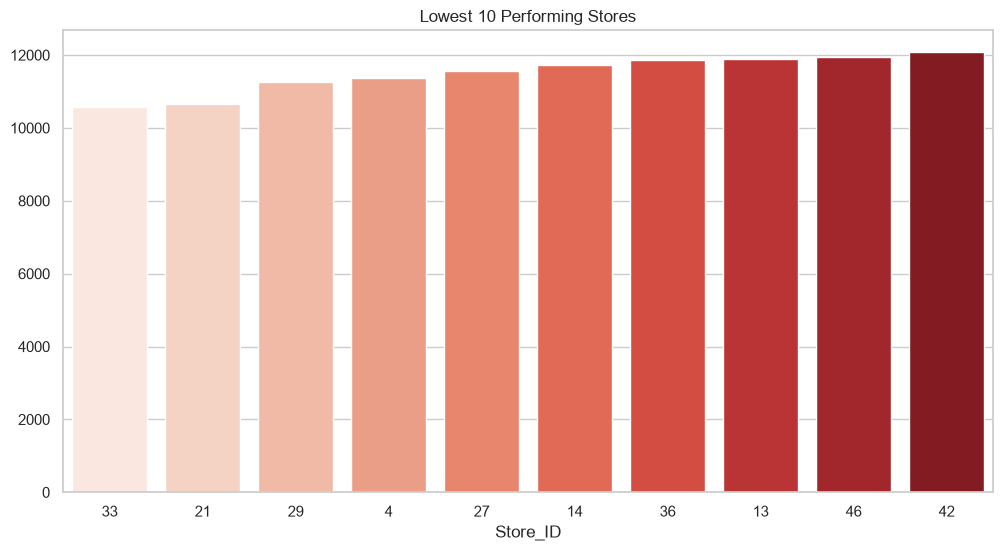

In [78]:
# ==============================================================================
# LOWEST 10 PERFORMING STORES
# ==============================================================================

low_store = (
    df.groupby("Store_ID")["Sales"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=low_store.index.astype(str),
    y=low_store.values,
    palette="Reds"
)

plt.title("Lowest 10 Performing Stores")

plt.show()

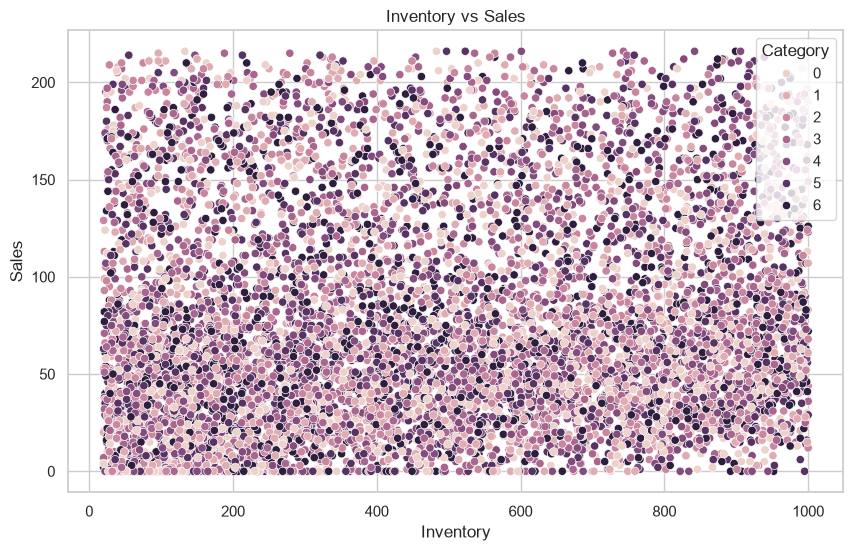

In [79]:
# ==============================================================================
# INVENTORY ANALYSIS
# ==============================================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Inventory",
    y="Sales",
    hue="Category"
)

plt.title("Inventory vs Sales")

plt.show()

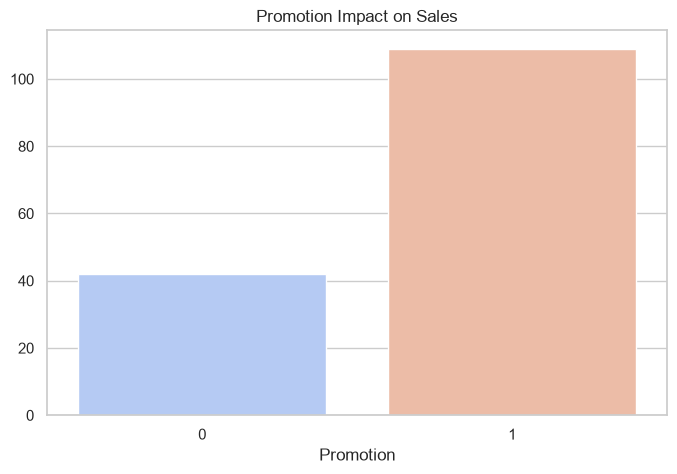

In [80]:
# ==============================================================================
# PROMOTION ANALYSIS
# ==============================================================================

promotion_sales = (
    df.groupby("Promotion")["Sales"]
      .mean()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=promotion_sales.index.astype(str),
    y=promotion_sales.values,
    palette="coolwarm"
)

plt.title("Promotion Impact on Sales")

plt.show()

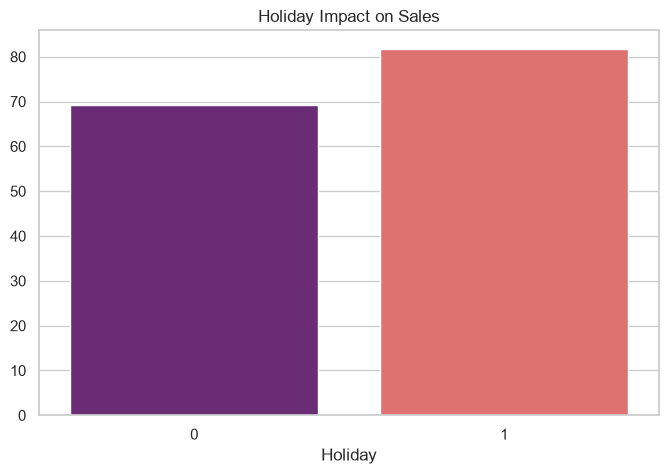

In [81]:
# ==============================================================================
# HOLIDAY ANALYSIS
# ==============================================================================

holiday_sales = (
    df.groupby("Holiday")["Sales"]
      .mean()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=holiday_sales.index.astype(str),
    y=holiday_sales.values,
    palette="magma"
)

plt.title("Holiday Impact on Sales")

plt.show()

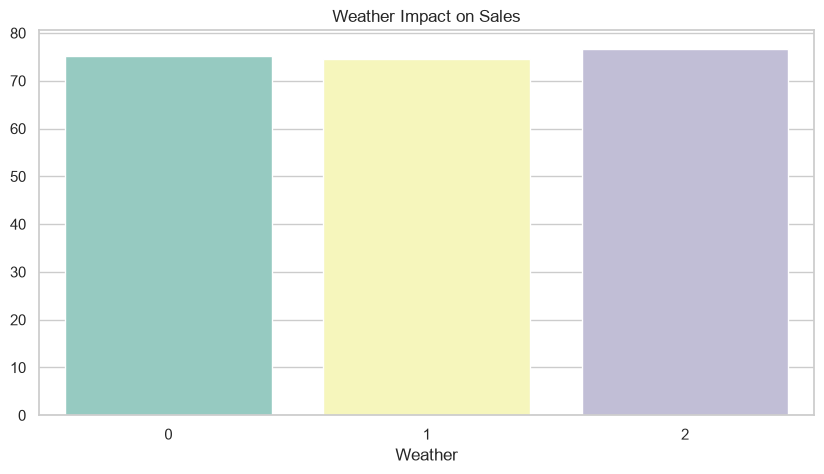

In [83]:
# ==============================================================================
# WEATHER ANALYSIS
# ==============================================================================

weather_sales = (
    df.groupby("Weather")["Sales"]
      .mean()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=weather_sales.index,
    y=weather_sales.values,
    palette="Set3"
)

plt.title("Weather Impact on Sales")

plt.show()

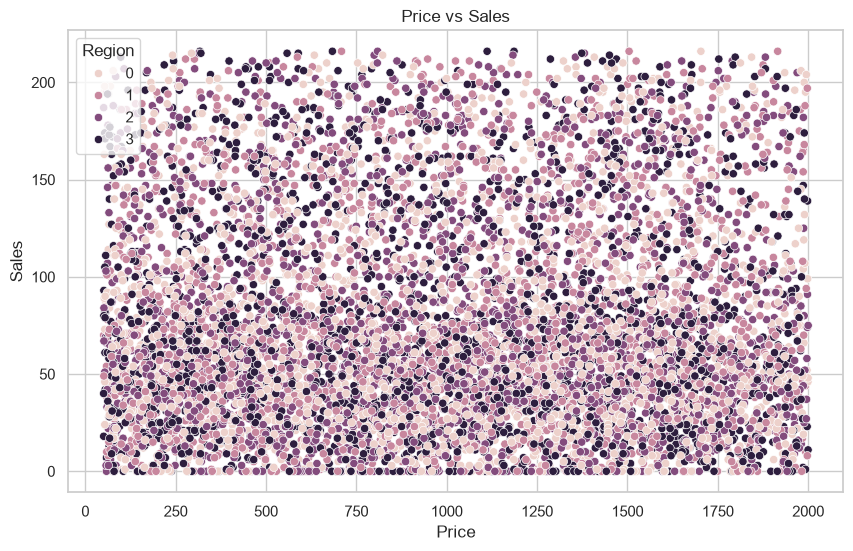

In [84]:
# ==============================================================================
# PRICE ANALYSIS
# ==============================================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Price",
    y="Sales",
    hue="Region"
)

plt.title("Price vs Sales")

plt.show()

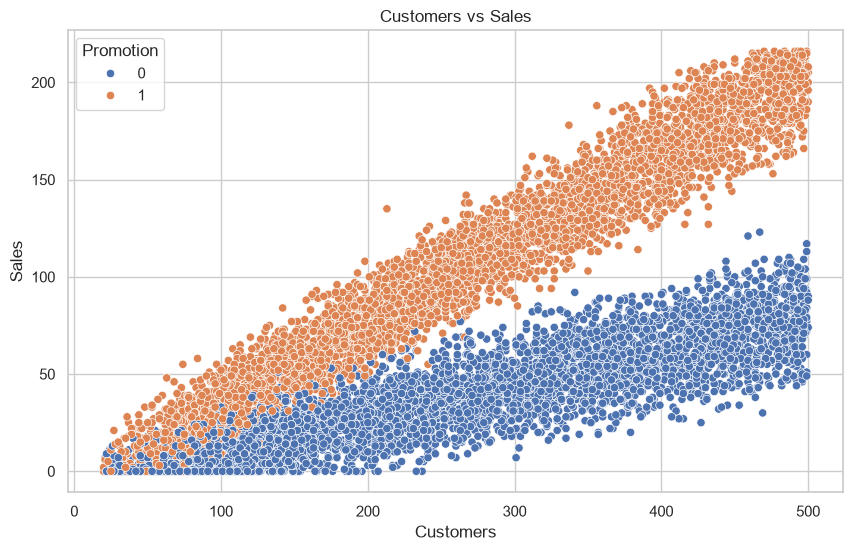

In [85]:
# ==============================================================================
# CUSTOMER ANALYSIS
# ==============================================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Customers",
    y="Sales",
    hue="Promotion"
)

plt.title("Customers vs Sales")

plt.show()

In [86]:
# ==============================================================================
# KEY PERFORMANCE INDICATORS (KPIs)
# ==============================================================================

print("=" * 50)
print("RETAIL DEMAND FORECASTING - KPI SUMMARY")
print("=" * 50)

print(f"Total Sales           : {df['Sales'].sum():,.2f}")
print(f"Average Sales         : {df['Sales'].mean():,.2f}")
print(f"Maximum Sales         : {df['Sales'].max():,.2f}")
print(f"Minimum Sales         : {df['Sales'].min():,.2f}")

print(f"Total Customers       : {df['Customers'].sum():,.0f}")
print(f"Average Customers     : {df['Customers'].mean():,.2f}")

print(f"Average Inventory     : {df['Inventory'].mean():,.2f}")
print(f"Average Discount (%)  : {df['Discount'].mean():,.2f}")

RETAIL DEMAND FORECASTING - KPI SUMMARY
Total Sales           : 649,379.00
Average Sales         : 75.50
Maximum Sales         : 216.00
Minimum Sales         : 0.00
Total Customers       : 2,405,297
Average Customers     : 279.65
Average Inventory     : 483.50
Average Discount (%)  : 24.73


In [87]:
# ==============================================================================
# TOP 5 REGIONS BY SALES
# ==============================================================================

top_regions = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

print(top_regions)

Region
3    165932
1    164202
2    160720
0    158525
Name: Sales, dtype: int64


In [88]:
# ==============================================================================
# TOP 5 CATEGORIES BY SALES
# ==============================================================================

top_categories = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

print(top_categories)

Category
6    96740
4    96729
3    94021
2    92148
0    91251
Name: Sales, dtype: int64


In [89]:
# ==============================================================================
# TOP 10 PRODUCTS
# ==============================================================================

top_products = (
    df.groupby("Product_ID")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(top_products.to_frame("Sales"))

,Sales
Product_ID,
1130,4913
1169,4753
1008,4751
1089,4635
1155,4540
1171,4358
1050,4323
1178,4280
1065,4279


In [90]:
# ==============================================================================
# STORE PERFORMANCE SUMMARY
# ==============================================================================

store_summary = (
    df.groupby("Store_ID")
      .agg(
          Total_Sales=("Sales","sum"),
          Average_Sales=("Sales","mean"),
          Total_Customers=("Customers","sum")
      )
      .sort_values("Total_Sales",ascending=False)
)

store_summary.head(10)

,Total_Sales,Average_Sales,Total_Customers
Store_ID,,,
38,15643,81.05,55274
3,15585,79.52,54500
49,15051,78.80,53708
9,14987,79.30,53644
26,14790,78.25,55010
35,14390,74.56,54404
8,14188,74.28,52274
45,14106,78.37,52452
28,14086,79.58,50165


In [91]:
# ==============================================================================
# STORE PERFORMANCE SUMMARY
# ==============================================================================

store_summary = (
    df.groupby("Store_ID")
      .agg(
          Total_Sales=("Sales","sum"),
          Average_Sales=("Sales","mean"),
          Total_Customers=("Customers","sum")
      )
      .sort_values("Total_Sales",ascending=False)
)

store_summary.head(10)

,Total_Sales,Average_Sales,Total_Customers
Store_ID,,,
38,15643,81.05,55274
3,15585,79.52,54500
49,15051,78.80,53708
9,14987,79.30,53644
26,14790,78.25,55010
35,14390,74.56,54404
8,14188,74.28,52274
45,14106,78.37,52452
28,14086,79.58,50165


In [92]:
# ==============================================================================
# BUSINESS INSIGHTS
# ==============================================================================

print("BUSINESS INSIGHTS")

print()

print("• Identify high-performing regions for future expansion.")

print("• Products with consistently high sales should be prioritized.")

print("• Promotional campaigns generally increase sales.")

print("• Higher customer footfall leads to increased revenue.")

print("• Inventory planning should align with seasonal demand.")

print("• Competitor pricing should be monitored regularly.")

BUSINESS INSIGHTS

• Identify high-performing regions for future expansion.
• Products with consistently high sales should be prioritized.
• Promotional campaigns generally increase sales.
• Higher customer footfall leads to increased revenue.
• Inventory planning should align with seasonal demand.
• Competitor pricing should be monitored regularly.


In [93]:
# ==============================================================================
# RECOMMENDATIONS
# ==============================================================================

recommendations = [

"Increase inventory in high-demand regions.",

"Offer targeted discounts instead of blanket discounts.",

"Strengthen promotional campaigns during holidays.",

"Optimize pricing using competitor price analysis.",

"Improve stock planning using demand forecasting.",

"Focus marketing on top-selling categories."

]

for i, rec in enumerate(recommendations,1):

    print(f"{i}. {rec}")

1. Increase inventory in high-demand regions.
2. Offer targeted discounts instead of blanket discounts.
3. Strengthen promotional campaigns during holidays.
4. Optimize pricing using competitor price analysis.
5. Improve stock planning using demand forecasting.
6. Focus marketing on top-selling categories.
